In [1]:
import pandas as pd
import matplotlib
import seaborn as sns


from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

In [2]:
urlArea = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/demo_r_d3area/1.0/*.*.*.*?c[freq]=A&c[unit]=KM2&c[landuse]=TOTAL&c[geo]=BE,BE1,BE10,BE100,BE2,BE21,BE211,BE212,BE213,BE22,BE221,BE222,BE223,BE23,BE231,BE232,BE233,BE234,BE235,BE236,BE24,BE241,BE242,BE25,BE251,BE252,BE253,BE254,BE255,BE256,BE257,BE258,BE3,BE31,BE310,BE32,BE321,BE322,BE323,BE324,BE325,BE326,BE327,BE33,BE331,BE332,BE334,BE335,BE336,BE34,BE341,BE342,BE343,BE344,BE345,BE35,BE351,BE352,BE353,BG,BG3,BG31,BG311,BG312,BG313,BG314,BG315,BG32,BG321,BG322,BG323,BG324,BG325,BG33,BG331,BG332,BG333,BG334,BG34,BG341,BG342,BG343,BG344,BG4,BG41,BG411,BG412,BG413,BG414,BG415,BG42,BG421,BG422,BG423,BG424,BG425,CZ,CZ0,CZ01,CZ010,CZ02,CZ020,CZ03,CZ031,CZ032,CZ04,CZ041,CZ042,CZ05,CZ051,CZ052,CZ053,CZ06,CZ063,CZ064,CZ07,CZ071,CZ072,CZ08,CZ080,DK,DK0,DK01,DK011,DK012,DK013,DK014,DK02,DK021,DK022,DK03,DK031,DK032,DK04,DK041,DK042,DK05,DK050,DE,DE1,DE11,DE111,DE112,DE113,DE114,DE115,DE116,DE117,DE118,DE119,DE11A,DE11B,DE11C,DE11D,DE12,DE121,DE122,DE123,DE124,DE125,DE126,DE127,DE128,DE129,DE12A,DE12B,DE12C,DE13,DE131,DE132,DE133,DE134,DE135,DE136,DE137,DE138,DE139,DE13A,DE14,DE141,DE142,DE143,DE144,DE145,DE146,DE147,DE148,DE149,DE2,DE21,DE211,DE212,DE213,DE214,DE215,DE216,DE217,DE218,DE219,DE21A,DE21B,DE21C,DE21D,DE21E,DE21F,DE21G,DE21H,DE21I,DE21J,DE21K,DE21L,DE21M,DE21N,DE22,DE221,DE222,DE223,DE224,DE225,DE226,DE227,DE228,DE229,DE22A,DE22B,DE22C,DE23,DE231,DE232,DE233,DE234,DE235,DE236,DE237,DE238,DE239,DE23A,DE24,DE241,DE242,DE243,DE244,DE245,DE246,DE247,DE248,DE249,DE24A,DE24B,DE24C,DE24D,DE25,DE251,DE252,DE253,DE254,DE255,DE256,DE257,DE258,DE259,DE25A,DE25B,DE25C,DE26,DE261,DE262,DE263,DE264,DE265,DE266,DE267,DE268,DE269,DE26A,DE26B,DE26C,DE27,DE271,DE272,DE273,DE274,DE275,DE276,DE277,DE278,DE279,DE27A,DE27B,DE27C,DE27D,DE27E,DE3,DE30,DE300,DE4,DE40,DE401,DE402,DE403,DE404,DE405,DE406,DE407,DE408,DE409,DE40A,DE40B,DE40C,DE40D,DE40E,DE40F,DE40G,DE40H,DE40I,DE5,DE50,DE501,DE502,DE6,DE60,DE600,DE7,DE71,DE711,DE712,DE713,DE714,DE715,DE716,DE717,DE718,DE719,DE71A,DE71B,DE71C,DE71D,DE71E,DE72,DE721,DE722,DE723,DE724,DE725,DE73,DE731,DE732,DE733,DE734,DE735,DE736,DE737,DE8,DE80,DE803,DE804,DE80J,DE80K,DE80L,DE80M,DE80N,DE80O,DE9,DE91,DE911,DE912,DE913,DE914,DE915,DE916,DE917,DE918,DE919,DE91A,DE91B,DE92,DE922,DE923,DE925,DE926,DE927,DE928,DE929,DE93,DE931,DE932,DE933,DE934,DE935,DE936,DE937,DE938,DE939,DE93A,DE93B,DE94,DE941,DE942,DE943,DE944,DE945,DE946,DE947,DE948,DE949,DE94A,DE94B,DE94C,DE94D,DE94E,DE94F,DE94G,DE94H,DEA,DEA1,DEA11,DEA12,DEA13,DEA14,DEA15,DEA16,DEA17,DEA18,DEA19,DEA1A,DEA1B,DEA1C,DEA1D,DEA1E,DEA1F,DEA2,DEA22,DEA23,DEA24,DEA26,DEA27,DEA28,DEA29,DEA2A,DEA2B,DEA2C,DEA2D,DEA3,DEA31,DEA32,DEA33,DEA34,DEA35,DEA36,DEA37,DEA38,DEA4,DEA41,DEA42,DEA43,DEA44,DEA45,DEA46,DEA47,DEA5,DEA51,DEA52,DEA53,DEA54,DEA55,DEA56,DEA57,DEA58,DEA59,DEA5A,DEA5B,DEA5C,DEB,DEB1,DEB11,DEB12,DEB13,DEB14,DEB15,DEB16,DEB17,DEB18,DEB19,DEB1A,DEB1B,DEB2,DEB21,DEB22,DEB23,DEB24,DEB25,DEB3,DEB31,DEB32,DEB33,DEB34,DEB35,DEB36,DEB37,DEB38,DEB39,DEB3A,DEB3B,DEB3C,DEB3D,DEB3E,DEB3F,DEB3G,DEB3H,DEB3I,DEB3J,DEB3K,DEC,DEC0,DEC01,DEC02,DEC03,DEC04,DEC05,DEC06,DED,DED2,DED21,DED2C,DED2D,DED2E,DED2F,DED4,DED41,DED42,DED43,DED44,DED45,DED5,DED51,DED52,DED53,DEE,DEE0,DEE01,DEE02,DEE03,DEE04,DEE05,DEE06,DEE07,DEE08,DEE09,DEE0A,DEE0B,DEE0C,DEE0D,DEE0E,DEF,DEF0,DEF01,DEF02,DEF03,DEF04,DEF05,DEF06,DEF07,DEF08,DEF09,DEF0A,DEF0B,DEF0C,DEF0D,DEF0E,DEF0F,DEG,DEG0,DEG01,DEG02,DEG03,DEG04,DEG05,DEG06,DEG07,DEG09,DEG0A,DEG0B,DEG0C,DEG0D,DEG0E,DEG0F,DEG0G,DEG0H,DEG0I,DEG0J,DEG0K,DEG0L,DEG0M,DEG0N,DEG0P,EE,EE0,EE00,EE001,EE004,EE006,EE007,EE008,IE,IE0,IE01,IE011,IE012,IE013,IE02,IE021,IE022,IE023,IE024,IE025,EL,EL3,EL30,EL301,EL302,EL303,EL304,EL305,EL306,EL307,EL4,EL41,EL411,EL412,EL413,EL42,EL421,EL422,EL43,EL431,EL432,EL433,EL434,EL5,EL51,EL511,EL512,EL513,EL514,EL515,EL52,EL521,EL522,EL523,EL524,EL525,EL526,EL527,EL53,EL531,EL532,EL533,EL54,EL541,EL542,EL543,EL6,EL61,EL611,EL612,EL613,EL62,EL621,EL622,EL623,EL624,EL63,EL631,EL632,EL633,EL64,EL641,EL642,EL643,EL644,EL645,EL65,EL651,EL652,EL653,ES,ES1,ES11,ES111,ES112,ES113,ES114,ES12,ES120,ES13,ES130,ES2,ES21,ES211,ES212,ES213,ES22,ES220,ES23,ES230,ES24,ES241,ES242,ES243,ES3,ES30,ES300,ES4,ES41,ES411,ES412,ES413,ES414,ES415,ES416,ES417,ES418,ES419,ES42,ES421,ES422,ES423,ES424,ES425,ES43,ES431,ES432,ES5,ES51,ES511,ES512,ES513,ES514,ES52,ES521,ES522,ES523,ES53,ES531,ES532,ES533,ES6,ES61,ES611,ES612,ES613,ES614,ES615,ES616,ES617,ES618,ES62,ES620,ES63,ES630,ES64,ES640,ES7,ES70,ES703,ES704,ES705,ES706,ES707,ES708,ES709,FR,FR1,FR10,FR101,FR102,FR103,FR104,FR105,FR106,FR107,FR108,FR2,FR21,FR211,FR212,FR213,FR214,FR22,FR221,FR222,FR223,FR23,FR231,FR232,FR24,FR241,FR242,FR243,FR244,FR245,FR246,FR25,FR251,FR252,FR253,FR26,FR261,FR262,FR263,FR264,FR3,FR30,FR301,FR302,FR4,FR41,FR411,FR412,FR413,FR414,FR42,FR421,FR422,FR43,FR431,FR432,FR433,FR434,FR5,FR51,FR511,FR512,FR513,FR514,FR515,FR52,FR521,FR522,FR523,FR524,FR53,FR531,FR532,FR533,FR534,FR6,FR61,FR611,FR612,FR613,FR614,FR615,FR62,FR621,FR622,FR623,FR624,FR625,FR626,FR627,FR628,FR63,FR631,FR632,FR633,FR7,FR71,FR711,FR712,FR713,FR714,FR715,FR716,FR717,FR718,FR72,FR721,FR722,FR723,FR724,FR8,FR81,FR811,FR812,FR813,FR814,FR815,FR82,FR821,FR822,FR823,FR824,FR825,FR826,FR83,FR831,FR832,FRA,FRA1,FRA10,FRA2,FRA20,FRA3,FRA30,FRA4,FRA40,FRA5,FRA50,HR,HR0,HR03,HR031,HR032,HR033,HR034,HR035,HR036,HR037,HR04,HR041,HR042,HR043,HR044,HR045,HR046,HR047,HR048,HR049,HR04A,HR04B,HR04C,HR04D,HR04E,IT,ITC,ITC1,ITC11,ITC12,ITC13,ITC14,ITC15,ITC16,ITC17,ITC18,ITC2,ITC20,ITC3,ITC31,ITC32,ITC33,ITC34,ITC4,ITC41,ITC42,ITC43,ITC44,ITC46,ITC47,ITC48,ITC49,ITC4A,ITC4B,ITC4C,ITC4D,ITF,ITF1,ITF11,ITF12,ITF13,ITF14,ITF2,ITF21,ITF22,ITF3,ITF31,ITF32,ITF33,ITF34,ITF35,ITF4,ITF43,ITF44,ITF45,ITF46,ITF47,ITF48,ITF5,ITF51,ITF52,ITF6,ITF61,ITF62,ITF63,ITF64,ITF65,ITG,ITG1,ITG11,ITG12,ITG13,ITG14,ITG15,ITG16,ITG17,ITG18,ITG19,ITG2,ITG25,ITG26,ITG27,ITG28,ITG29,ITG2A,ITG2B,ITG2C,ITH,ITH1,ITH10,ITH2,ITH20,ITH3,ITH31,ITH32,ITH33,ITH34,ITH35,ITH36,ITH37,ITH4,ITH41,ITH42,ITH43,ITH44,ITH5,ITH51,ITH52,ITH53,ITH54,ITH55,ITH56,ITH57,ITH58,ITH59,ITI,ITI1,ITI11,ITI12,ITI13,ITI14,ITI15,ITI16,ITI17,ITI18,ITI19,ITI1A,ITI2,ITI21,ITI22,ITI3,ITI31,ITI32,ITI33,ITI34,ITI35,ITI4,ITI41,ITI42,ITI43,ITI44,ITI45,CY,CY0,CY00,CY000,LV,LV0,LV00,LV003,LV005,LV006,LV007,LV008,LV009,LT,LT0,LT00,LT001,LT002,LT003,LT004,LT005,LT006,LT007,LT008,LT009,LT00A,LU,LU0,LU00,LU000,HU,HU1,HU10,HU101,HU102,HU2,HU21,HU211,HU212,HU213,HU22,HU221,HU222,HU223,HU23,HU231,HU232,HU233,HU3,HU31,HU311,HU312,HU313,HU32,HU321,HU322,HU323,HU33,HU331,HU332,HU333,MT,MT0,MT00,MT001,MT002,NL,NL1,NL11,NL111,NL112,NL113,NL12,NL121,NL122,NL123,NL13,NL131,NL132,NL133,NL2,NL21,NL211,NL212,NL213,NL22,NL221,NL224,NL225,NL226,NL23,NL230,NL3,NL31,NL310,NL32,NL321,NL322,NL323,NL324,NL325,NL326,NL327,NL33,NL332,NL333,NL337,NL338,NL339,NL33A,NL34,NL341,NL342,NL4,NL41,NL411,NL412,NL413,NL414,NL42,NL421,NL422,NL423,AT,AT1,AT11,AT111,AT112,AT113,AT12,AT121,AT122,AT123,AT124,AT125,AT126,AT127,AT13,AT130,AT2,AT21,AT211,AT212,AT213,AT22,AT221,AT222,AT223,AT224,AT225,AT226,AT3,AT31,AT311,AT312,AT313,AT314,AT315,AT32,AT321,AT322,AT323,AT33,AT331,AT332,AT333,AT334,AT335,AT34,AT341,AT342,PL,PL1,PL11,PL113,PL114,PL115,PL116,PL117,PL12,PL127,PL128,PL129,PL12A,PL12B,PL12C,PL12D,PL12E,PL2,PL21,PL213,PL214,PL217,PL218,PL219,PL21A,PL22,PL224,PL225,PL227,PL228,PL229,PL22A,PL22B,PL22C,PL3,PL31,PL311,PL312,PL314,PL315,PL32,PL323,PL324,PL325,PL326,PL33,PL331,PL332,PL34,PL343,PL344,PL345,PL4,PL41,PL411,PL414,PL415,PL416,PL417,PL418,PL42,PL424,PL426,PL427,PL428,PL43,PL431,PL432,PL5,PL51,PL514,PL515,PL516,PL517,PL518,PL52,PL523,PL524,PL6,PL61,PL613,PL616,PL617,PL618,PL619,PL62,PL621,PL622,PL623,PL63,PL633,PL634,PL636,PL637,PL638,PT,PT1,PT11,PT111,PT112,PT119,PT11A,PT11B,PT11C,PT11D,PT11E,PT15,PT150,PT16,PT16B,PT16D,PT16E,PT16F,PT16G,PT16H,PT16I,PT16J,PT17,PT170,PT18,PT181,PT184,PT185,PT186,PT187,PT2,PT20,PT200,PT3,PT30,PT300,RO,RO1,RO11,RO111,RO112,RO113,RO114,RO115,RO116,RO12,RO121,RO122,RO123,RO124,RO125,RO126,RO2,RO21,RO211,RO212,RO213,RO214,RO215,RO216,RO22,RO221,RO222,RO223,RO224,RO225,RO226,RO3,RO31,RO311,RO312,RO313,RO314,RO315,RO316,RO317,RO32,RO321,RO322,RO4,RO41,RO411,RO412,RO413,RO414,RO415,RO42,RO421,RO422,RO423,RO424,SI,SI0,SI03,SI031,SI032,SI033,SI034,SI035,SI036,SI037,SI038,SI04,SI041,SI042,SI043,SI044,SK,SK0,SK01,SK010,SK02,SK021,SK022,SK023,SK03,SK031,SK032,SK04,SK041,SK042,FI,FI1,FI19,FI193,FI194,FI195,FI196,FI197,FI1B,FI1B1,FI1C,FI1C1,FI1C2,FI1C3,FI1C4,FI1C5,FI1D,FI1D1,FI1D2,FI1D3,FI1D4,FI1D5,FI1D6,FI1D7,FI2,FI20,FI200,SE,SE1,SE11,SE110,SE12,SE121,SE122,SE123,SE124,SE125,SE2,SE21,SE211,SE212,SE213,SE214,SE22,SE221,SE224,SE23,SE231,SE232,SE3,SE31,SE311,SE312,SE313,SE32,SE321,SE322,SE33,SE331,SE332,IS,IS0,IS00,IS001,IS002,LI,LI0,LI00,LI000,NO,NO0,NO01,NO011,NO012,NO02,NO021,NO022,NO03,NO031,NO032,NO033,NO034,NO04,NO041,NO042,NO043,NO05,NO051,NO052,NO053,NO06,NO060,NO061,NO062,NO07,NO071,NO072,NO073,CH,CH0,CH01,CH011,CH012,CH013,CH02,CH021,CH022,CH023,CH024,CH025,CH03,CH031,CH032,CH033,CH04,CH040,CH05,CH051,CH052,CH053,CH054,CH055,CH056,CH057,CH06,CH061,CH062,CH063,CH064,CH065,CH066,CH07,CH070,UK,UKC,UKC1,UKC11,UKC12,UKC13,UKC14,UKC2,UKC21,UKC22,UKC23,UKD,UKD1,UKD11,UKD12,UKD3,UKD33,UKD34,UKD35,UKD36,UKD37,UKD4,UKD41,UKD42,UKD44,UKD45,UKD46,UKD47,UKD6,UKD61,UKD62,UKD63,UKD7,UKD71,UKD72,UKD73,UKD74,UKE,UKE1,UKE11,UKE12,UKE13,UKE2,UKE21,UKE22,UKE3,UKE31,UKE32,UKE4,UKE41,UKE42,UKE44,UKE45,UKF,UKF1,UKF11,UKF12,UKF13,UKF14,UKF15,UKF16,UKF2,UKF21,UKF22,UKF24,UKF25,UKF3,UKF30,UKG,UKG1,UKG11,UKG12,UKG13,UKG2,UKG21,UKG22,UKG23,UKG24,UKG3,UKG31,UKG32,UKG33,UKG36,UKG37,UKG38,UKG39,UKH,UKH1,UKH11,UKH12,UKH14,UKH15,UKH16,UKH17,UKH2,UKH21,UKH23,UKH24,UKH25,UKH3,UKH31,UKH32,UKH34,UKH35,UKH36,UKH37,UKI,UKI3,UKI31,UKI32,UKI33,UKI34,UKI4,UKI41,UKI42,UKI43,UKI44,UKI45,UKI5,UKI51,UKI52,UKI53,UKI54,UKI6,UKI61,UKI62,UKI63,UKI7,UKI71,UKI72,UKI73,UKI74,UKI75,UKJ,UKJ1,UKJ11,UKJ12,UKJ13,UKJ14,UKJ2,UKJ21,UKJ22,UKJ25,UKJ26,UKJ27,UKJ28,UKJ3,UKJ31,UKJ32,UKJ34,UKJ35,UKJ36,UKJ37,UKJ4,UKJ41,UKJ43,UKJ44,UKJ45,UKJ46,UKK,UKK1,UKK11,UKK12,UKK13,UKK14,UKK15,UKK2,UKK21,UKK22,UKK23,UKK3,UKK30,UKK4,UKK41,UKK42,UKK43,UKL,UKL1,UKL11,UKL12,UKL13,UKL14,UKL15,UKL16,UKL17,UKL18,UKL2,UKL21,UKL22,UKL23,UKL24,UKM,UKM2,UKM21,UKM22,UKM23,UKM24,UKM25,UKM26,UKM27,UKM28,UKM3,UKM31,UKM32,UKM33,UKM34,UKM35,UKM36,UKM37,UKM38,UKM5,UKM50,UKM6,UKM61,UKM62,UKM63,UKM64,UKM65,UKM66,UKN,UKN0,UKN01,UKN02,UKN03,UKN04,UKN05,ME,ME0,ME00,ME000,MK,MK0,MK00,MK001,MK002,MK003,MK004,MK005,MK006,MK007,MK008,AL,AL0,AL01,AL011,AL012,AL013,AL014,AL015,AL02,AL021,AL022,AL03,AL031,AL032,AL033,AL034,AL035,TR,TR1,TR10,TR100,TR2,TR21,TR211,TR212,TR213,TR22,TR221,TR222,TR3,TR31,TR310,TR32,TR321,TR322,TR323,TR33,TR331,TR332,TR333,TR334,TR4,TR41,TR411,TR412,TR413,TR42,TR421,TR422,TR423,TR424,TR425,TR5,TR51,TR510,TR52,TR521,TR522,TR6,TR61,TR611,TR612,TR613,TR62,TR621,TR622,TR63,TR631,TR632,TR633,TR7,TR71,TR711,TR712,TR713,TR714,TR715,TR72,TR721,TR722,TR723,TR8,TR81,TR811,TR812,TR813,TR82,TR821,TR822,TR823,TR83,TR831,TR832,TR833,TR834,TR9,TR90,TR901,TR902,TR903,TR904,TR905,TR906,TRA,TRA1,TRA11,TRA12,TRA13,TRA2,TRA21,TRA22,TRA23,TRA24,TRB,TRB1,TRB11,TRB12,TRB13,TRB14,TRB2,TRB21,TRB22,TRB23,TRB24,TRC,TRC1,TRC11,TRC12,TRC13,TRC2,TRC21,TRC22,TRC3,TRC31,TRC32,TRC33,TRC34&c[TIME_PERIOD]=2015&compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=both'
urlLengthRailways = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/rail_if_line_na/1.0?compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only'
urlNumberPassengersPerState = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/rail_pa_total/1.0?compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only'

In [3]:
df = pd.read_csv(urlNumberPassengersPerState, sep=",", compression="gzip")
dfPassengers = pd.read_csv("railways-passengers-km.csv")
dfRailways = pd.read_csv("km_railways.csv", sep=",")
dfGDPCapita = pd.read_csv("GDP_capita.csv", sep=",")
dfPopulationCSV = pd.read_csv("population.csv", sep=",")
df.head()

dfLength = pd.read_csv(urlLengthRailways, sep=",", compression="gzip")
dfArea = pd.read_csv(urlArea, sep=",", compression="gzip")

In [4]:
df.describe()

,TIME_PERIOD,OBS_VALUE,OBS_FLAG
count,1387.000000,1.286000e+03,0.0
mean,2014.451334,1.508357e+05,NaN
std,6.069431,3.933328e+05,NaN
min,2004.000000,1.000000e+00,NaN
25%,2009.000000,2.416000e+03,NaN
50%,2015.000000,1.573300e+04,NaN
75%,2020.000000,8.416650e+04,NaN
max,2025.000000,2.938023e+06,NaN


In [5]:
df["freq"].unique

<bound method Series.unique of 0       Annual
1       Annual
2       Annual
3       Annual
4       Annual
         ...  
1382    Annual
1383    Annual
1384    Annual
1385    Annual
1386    Annual
Name: freq, Length: 1387, dtype: str>

In [6]:
df["freq"].value_counts()

freq
Annual    1387
Name: count, dtype: int64

In [7]:
# freq sempre Annual quindi possiamo toglierla

In [8]:
df = df.drop("DATAFLOW", axis=1)

In [9]:
df.head()

,LAST UPDATE,freq,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,24/06/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2004,8274.0,NaN,NaN
1,24/06/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2005,8685.0,NaN,NaN
2,24/06/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2006,8907.0,NaN,NaN
3,24/06/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2007,9167.0,NaN,NaN
4,24/06/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2008,10365.0,NaN,NaN


In [10]:
df = df.drop("LAST UPDATE", axis=1)

In [11]:
df = df.drop("freq", axis=1)

In [12]:
df

,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,Millions of passenger-kilometres,Austria,2004,8274.0,NaN,NaN
1,Millions of passenger-kilometres,Austria,2005,8685.0,NaN,NaN
2,Millions of passenger-kilometres,Austria,2006,8907.0,NaN,NaN
3,Millions of passenger-kilometres,Austria,2007,9167.0,NaN,NaN
4,Millions of passenger-kilometres,Austria,2008,10365.0,NaN,NaN
...,...,...,...,...,...,...
1382,Thousand passengers,United Kingdom,2015,1741562.0,NaN,NaN
1383,Thousand passengers,United Kingdom,2016,1772563.0,NaN,NaN
1384,Thousand passengers,United Kingdom,2017,1757359.0,NaN,NaN
1385,Thousand passengers,United Kingdom,2018,1783232.0,NaN,NaN


In [13]:
df["unit"].value_counts()

unit
Millions of passenger-kilometres    715
Thousand passengers                 672
Name: count, dtype: int64

In [14]:
# Abbiamo due unite diverse millioni di passegger x chilometri e migliaia di passeggeri.
# Dobbiamo sceglierne una

In [15]:
df

,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,Millions of passenger-kilometres,Austria,2004,8274.0,NaN,NaN
1,Millions of passenger-kilometres,Austria,2005,8685.0,NaN,NaN
2,Millions of passenger-kilometres,Austria,2006,8907.0,NaN,NaN
3,Millions of passenger-kilometres,Austria,2007,9167.0,NaN,NaN
4,Millions of passenger-kilometres,Austria,2008,10365.0,NaN,NaN
...,...,...,...,...,...,...
1382,Thousand passengers,United Kingdom,2015,1741562.0,NaN,NaN
1383,Thousand passengers,United Kingdom,2016,1772563.0,NaN,NaN
1384,Thousand passengers,United Kingdom,2017,1757359.0,NaN,NaN
1385,Thousand passengers,United Kingdom,2018,1783232.0,NaN,NaN


In [16]:
df = df.sort_values('OBS_VALUE')

In [17]:
df

,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
397,Millions of passenger-kilometres,Liechtenstein,2013,1.0,NaN,NaN
388,Millions of passenger-kilometres,Liechtenstein,2004,1.0,NaN,NaN
389,Millions of passenger-kilometres,Liechtenstein,2005,1.0,NaN,NaN
390,Millions of passenger-kilometres,Liechtenstein,2006,1.0,NaN,NaN
391,Millions of passenger-kilometres,Liechtenstein,2007,1.0,NaN,NaN
...,...,...,...,...,...,...
1232,Thousand passengers,Poland,2020,NaN,NaN,C
1233,Thousand passengers,Poland,2021,NaN,NaN,C
1234,Thousand passengers,Poland,2022,NaN,NaN,C
1235,Thousand passengers,Poland,2023,NaN,NaN,C


In [18]:
df["OBS_VALUE"].isna().sum()

np.int64(101)

In [19]:
df['CONF_STATUS'].unique()

<ArrowStringArray>
[nan, 'C']
Length: 2, dtype: str

In [20]:
# Rimuovo OBS_VALUE = NaN

In [21]:
# df = df.dropna(subset=["OBS_VALUE"])
# Non rimuoviamo gli NA per poter fare interpolazione dei dati mancanti dopo

In [22]:
df

,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
397,Millions of passenger-kilometres,Liechtenstein,2013,1.0,NaN,NaN
388,Millions of passenger-kilometres,Liechtenstein,2004,1.0,NaN,NaN
389,Millions of passenger-kilometres,Liechtenstein,2005,1.0,NaN,NaN
390,Millions of passenger-kilometres,Liechtenstein,2006,1.0,NaN,NaN
391,Millions of passenger-kilometres,Liechtenstein,2007,1.0,NaN,NaN
...,...,...,...,...,...,...
1232,Thousand passengers,Poland,2020,NaN,NaN,C
1233,Thousand passengers,Poland,2021,NaN,NaN,C
1234,Thousand passengers,Poland,2022,NaN,NaN,C
1235,Thousand passengers,Poland,2023,NaN,NaN,C


In [23]:
df["OBS_FLAG"].value_counts()

Series([], Name: count, dtype: int64)

In [24]:
df["unit"].value_counts()

unit
Millions of passenger-kilometres    715
Thousand passengers                 672
Name: count, dtype: int64

In [25]:
df = df.drop("OBS_FLAG", axis=1)

In [26]:
df = df.drop("CONF_STATUS", axis=1)

In [27]:
df = df[df['TIME_PERIOD'] < 2025]

In [28]:
df.columns

Index(['unit', 'geo', 'TIME_PERIOD', 'OBS_VALUE'], dtype='str')

In [29]:
dfLength.columns

Index(['DATAFLOW', 'LAST UPDATE', 'freq', 'unit', 'tra_infr', 'tra_meas',
       'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS'],
      dtype='str')

In [30]:
dfLength["unit"].value_counts()

unit
Kilometre    12556
Name: count, dtype: int64

In [31]:
df[df['geo'] == 'Germany']

,unit,geo,TIME_PERIOD,OBS_VALUE
127,Millions of passenger-kilometres,Germany,2021,57518.0
126,Millions of passenger-kilometres,Germany,2020,57787.0
111,Millions of passenger-kilometres,Germany,2005,74944.0
110,Millions of passenger-kilometres,Germany,2004,75903.0
112,Millions of passenger-kilometres,Germany,2006,78735.0
113,Millions of passenger-kilometres,Germany,2007,79098.0
115,Millions of passenger-kilometres,Germany,2009,81206.0
114,Millions of passenger-kilometres,Germany,2008,82428.0
116,Millions of passenger-kilometres,Germany,2010,82837.0
117,Millions of passenger-kilometres,Germany,2011,89316.0


In [32]:
df[df['unit'] == 'Millions of passenger-kilometres']

,unit,geo,TIME_PERIOD,OBS_VALUE
397,Millions of passenger-kilometres,Liechtenstein,2013,1.0
388,Millions of passenger-kilometres,Liechtenstein,2004,1.0
389,Millions of passenger-kilometres,Liechtenstein,2005,1.0
390,Millions of passenger-kilometres,Liechtenstein,2006,1.0
391,Millions of passenger-kilometres,Liechtenstein,2007,1.0
...,...,...,...,...
560,Millions of passenger-kilometres,Poland,2020,NaN
561,Millions of passenger-kilometres,Poland,2021,NaN
562,Millions of passenger-kilometres,Poland,2022,NaN
563,Millions of passenger-kilometres,Poland,2023,NaN


In [33]:
df[df['unit'] == 'Thousand passengers']

,unit,geo,TIME_PERIOD,OBS_VALUE
1066,Thousand passengers,Liechtenstein,2011,96.0
1067,Thousand passengers,Liechtenstein,2012,96.0
1068,Thousand passengers,Liechtenstein,2013,96.0
1065,Thousand passengers,Liechtenstein,2010,96.0
1064,Thousand passengers,Liechtenstein,2009,97.0
...,...,...,...,...
1232,Thousand passengers,Poland,2020,NaN
1233,Thousand passengers,Poland,2021,NaN
1234,Thousand passengers,Poland,2022,NaN
1235,Thousand passengers,Poland,2023,NaN


In [34]:
# Tolgo dati totali paesi

In [35]:
df = df[~df["geo"].str.contains("European Union", na=False)]

In [36]:
# Tengo solo unit Thousand passengers

In [37]:
df = df[~df["unit"].str.contains("Thousand passengers", na=False)]

In [38]:
df


,unit,geo,TIME_PERIOD,OBS_VALUE
397,Millions of passenger-kilometres,Liechtenstein,2013,1.0
388,Millions of passenger-kilometres,Liechtenstein,2004,1.0
389,Millions of passenger-kilometres,Liechtenstein,2005,1.0
390,Millions of passenger-kilometres,Liechtenstein,2006,1.0
391,Millions of passenger-kilometres,Liechtenstein,2007,1.0
...,...,...,...,...
560,Millions of passenger-kilometres,Poland,2020,NaN
561,Millions of passenger-kilometres,Poland,2021,NaN
562,Millions of passenger-kilometres,Poland,2022,NaN
563,Millions of passenger-kilometres,Poland,2023,NaN


In [39]:
df = df.sort_values(["geo", "TIME_PERIOD"])

In [40]:
df.head(20)

,unit,geo,TIME_PERIOD,OBS_VALUE
0,Millions of passenger-kilometres,Austria,2004,8274.0
1,Millions of passenger-kilometres,Austria,2005,8685.0
2,Millions of passenger-kilometres,Austria,2006,8907.0
3,Millions of passenger-kilometres,Austria,2007,9167.0
4,Millions of passenger-kilometres,Austria,2008,10365.0
5,Millions of passenger-kilometres,Austria,2009,10184.0
6,Millions of passenger-kilometres,Austria,2010,10263.0
7,Millions of passenger-kilometres,Austria,2011,10778.0
8,Millions of passenger-kilometres,Austria,2012,11211.0
9,Millions of passenger-kilometres,Austria,2013,11804.0


In [41]:
df = df.rename(columns={"OBS_VALUE": "Passengers_Mil_KM"})

In [42]:
df

,unit,geo,TIME_PERIOD,Passengers_Mil_KM
0,Millions of passenger-kilometres,Austria,2004,8274.0
1,Millions of passenger-kilometres,Austria,2005,8685.0
2,Millions of passenger-kilometres,Austria,2006,8907.0
3,Millions of passenger-kilometres,Austria,2007,9167.0
4,Millions of passenger-kilometres,Austria,2008,10365.0
...,...,...,...,...
710,Millions of passenger-kilometres,United Kingdom,2015,66594.0
711,Millions of passenger-kilometres,United Kingdom,2016,68010.0
712,Millions of passenger-kilometres,United Kingdom,2017,68912.0
713,Millions of passenger-kilometres,United Kingdom,2018,69706.0


In [43]:
df = df.drop("unit", axis=1)

In [44]:
dfPassengers['Railways, passengers carried (passenger-km)'] = dfPassengers['Railways, passengers carried (passenger-km)'] / 1000000



In [45]:
dfPassengers[dfPassengers['Entity'] == 'Austria']

,Entity,Code,Year,"Railways, passengers carried (passenger-km)"
113,Austria,AUT,1995,9625.000
114,Austria,AUT,1996,9689.000
115,Austria,AUT,1997,8140.000
116,Austria,AUT,1998,7971.000
117,Austria,AUT,1999,7995.000
118,Austria,AUT,2000,8206.000
119,Austria,AUT,2001,8240.000
120,Austria,AUT,2002,8300.000
121,Austria,AUT,2003,8249.000
122,Austria,AUT,2004,8295.000


In [46]:
df[df['geo'] == 'Austria']

,geo,TIME_PERIOD,Passengers_Mil_KM
0,Austria,2004,8274.0
1,Austria,2005,8685.0
2,Austria,2006,8907.0
3,Austria,2007,9167.0
4,Austria,2008,10365.0
5,Austria,2009,10184.0
6,Austria,2010,10263.0
7,Austria,2011,10778.0
8,Austria,2012,11211.0
9,Austria,2013,11804.0


In [47]:
# Leggo altro dataset se il valore e' Nan

merged = df.merge(
    dfPassengers,
    left_on=["geo", "TIME_PERIOD"],
    right_on=["Entity","Year"],
    how="left"
)

merged["Passengers_Mil_KM"] = merged["Passengers_Mil_KM"].fillna(merged["Railways, passengers carried (passenger-km)"])
merged = merged.iloc[:, :3]
df = merged

In [48]:
dfLength[dfLength['geo'] == 'Austria']

,DATAFLOW,LAST UPDATE,freq,unit,tra_infr,tra_meas,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
33,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Electrified railway lines,Freight only,Austria,1999,0.0,NaN,NaN
34,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Electrified railway lines,Freight only,Austria,2000,0.0,NaN,NaN
35,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Electrified railway lines,Freight only,Austria,2001,0.0,NaN,NaN
36,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Electrified railway lines,Freight only,Austria,2002,0.0,NaN,NaN
37,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Electrified railway lines,Freight only,Austria,2003,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
11325,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Total,Total,Austria,2020,5607.0,NaN,NaN
11326,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Total,Total,Austria,2021,5603.0,NaN,NaN
11327,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Total,Total,Austria,2022,5575.0,NaN,NaN
11328,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Total,Total,Austria,2023,5577.0,NaN,NaN


In [49]:
dfLength['tra_meas'].unique()

<ArrowStringArray>
['Freight only', 'Passengers and freight', 'Passengers only', 'Total']
Length: 4, dtype: str

In [50]:
dfl1 = dfLength[(dfLength['tra_infr'] == 'Total') & (dfLength['tra_meas'] == 'Total')][['geo', 'TIME_PERIOD', 'OBS_VALUE']]
dfl1 = dfl1.groupby(['geo', 'TIME_PERIOD']).sum().reset_index()

In [51]:
dfl1[(dfl1['geo'] == 'Austria') & (dfl1['TIME_PERIOD'] == 2004)]

,geo,TIME_PERIOD,OBS_VALUE
49,Austria,2004,5675.0


In [52]:
df = df.merge(
    dfl1,
    on=["geo", "TIME_PERIOD"],
    how="left"
)

In [53]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,OBS_VALUE
0,Austria,2004,8274.0,5675.0
1,Austria,2005,8685.0,5691.0
2,Austria,2006,8907.0,5702.0
3,Austria,2007,9167.0,5702.0
4,Austria,2008,10365.0,5693.0
...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0
655,United Kingdom,2016,68010.0,16253.0
656,United Kingdom,2017,68912.0,16320.0
657,United Kingdom,2018,69706.0,16289.0


In [54]:
df = df.rename(columns={"OBS_VALUE": "km_railways"})

In [55]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways
0,Austria,2004,8274.0,5675.0
1,Austria,2005,8685.0,5691.0
2,Austria,2006,8907.0,5702.0
3,Austria,2007,9167.0,5702.0
4,Austria,2008,10365.0,5693.0
...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0
655,United Kingdom,2016,68010.0,16253.0
656,United Kingdom,2017,68912.0,16320.0
657,United Kingdom,2018,69706.0,16289.0


In [56]:
df[df['geo'] == 'Kosovo*']

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways


In [57]:
df[df["geo"].str.contains("Kosovo", na=False)]

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways


In [58]:
df.head(20)

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways
0,Austria,2004,8274.0,5675.0
1,Austria,2005,8685.0,5691.0
2,Austria,2006,8907.0,5702.0
3,Austria,2007,9167.0,5702.0
4,Austria,2008,10365.0,5693.0
5,Austria,2009,10184.0,5693.0
6,Austria,2010,10263.0,5828.0
7,Austria,2011,10778.0,5500.0
8,Austria,2012,11211.0,5566.0
9,Austria,2013,11804.0,5531.0


In [59]:
df["geo"].unique().size

np.int64(34)

In [60]:
dfTemp = (df.groupby("TIME_PERIOD"))

In [61]:
dfTemp

In [62]:
df_grouped = dfTemp.size().reset_index(name="count")

In [63]:
df_grouped

,TIME_PERIOD,count
0,2004,28
1,2005,28
2,2006,29
3,2007,29
4,2008,30
5,2009,30
6,2010,31
7,2011,31
8,2012,30
9,2013,32


In [64]:
dfTemp = (df.groupby("geo"))

In [65]:
df_grouped = dfTemp.size().reset_index(name="count")

In [66]:
df_grouped

,geo,count
0,Austria,21
1,Belgium,20
2,Bosnia and Herzegovina,11
3,Bulgaria,19
4,Croatia,21
5,Czechia,21
6,Denmark,21
7,Estonia,21
8,Finland,21
9,France,21


In [67]:
df[df['geo'] == 'Poland']

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways
453,Poland,2004,18430.0,20250.0
454,Poland,2005,17882.0,20253.0
455,Poland,2006,18240.0,20176.0
456,Poland,2007,19524.0,20107.0
457,Poland,2008,19762.0,20196.0
458,Poland,2009,18128.0,20360.0
459,Poland,2010,17485.0,20228.0
460,Poland,2011,17633.0,20228.0
461,Poland,2012,17674.0,20094.0
462,Poland,2013,16659.0,19328.0


In [68]:
df[df['geo'] == 'Italy']

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways
281,Italy,2004,49254.0,15916.0
282,Italy,2005,50088.0,16225.0
283,Italy,2006,50185.0,16295.0
284,Italy,2007,49780.0,16335.0
285,Italy,2008,49524.0,16529.0
286,Italy,2009,48124.0,16686.0
287,Italy,2010,47172.0,16704.0
288,Italy,2011,46845.0,16726.0
289,Italy,2012,46759.0,16742.0
290,Italy,2013,48739.0,16752.0


In [69]:
# Se valor nulli prendo dataset da WorldBank

for row in df.itertuples():
    if pd.isna(row.km_railways):

        dfRailwaysTemp = dfRailways[dfRailways["Country Name"] == row.geo]
        s = (row.TIME_PERIOD)
        match = dfRailwaysTemp[str(s)].iloc[0]
        if match > 0:
             df.loc[row.Index, "km_railways"] = match

In [70]:
urlPopulation = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/demo_urespop/1.0?compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only'
urlPopulation = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/demo_pjan/1.0/*.*.*.*.*?c[freq]=A&c[unit]=NR&c[age]=TOTAL&c[sex]=T&c[geo]=BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,FX,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE,IS,LI,NO,CH,UK,BA,ME,MD,MK,GE,AL,RS,TR,UA,XK,AD,BY,MC,RU,SM,AM,AZ&c[TIME_PERIOD]=2025,2024,2023,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013,2012,2011,2010,2009,2008,2007,2006,2005,2004&compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only'

In [71]:
dfPopulation = pd.read_csv(urlPopulation, sep=",", compression="gzip")

In [72]:
dfPopulation

,DATAFLOW,LAST UPDATE,freq,unit,age,sex,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Andorra,2004,72320,NaN,NaN
1,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Andorra,2005,76875,NaN,NaN
2,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Andorra,2006,78549,NaN,NaN
3,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Andorra,2007,81222,NaN,NaN
4,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Andorra,2008,83137,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
989,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Kosovo*,2018,1798506,NaN,NaN
990,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Kosovo*,2019,1795666,NaN,NaN
991,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Kosovo*,2020,1782115,NaN,NaN
992,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Kosovo*,2021,1798186,NaN,NaN


In [73]:
dfPopulation.describe()

,TIME_PERIOD,OBS_VALUE,CONF_STATUS
count,994.000000,9.940000e+02,0.0
mean,2014.048290,1.670366e+07,NaN
std,6.329305,2.552668e+07,NaN
min,2004.000000,2.924100e+04,NaN
25%,2009.000000,2.124639e+06,NaN
50%,2014.000000,5.764980e+06,NaN
75%,2019.000000,1.106978e+07,NaN
max,2025.000000,1.441682e+08,NaN


In [74]:
dfPopulation = dfPopulation.drop("DATAFLOW", axis=1)
dfPopulation = dfPopulation.drop("LAST UPDATE", axis=1)
dfPopulation = dfPopulation.drop("freq", axis=1)
dfPopulation = dfPopulation.drop("unit", axis=1)

In [75]:
dfPopulation

,age,sex,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,Total,Total,Andorra,2004,72320,NaN,NaN
1,Total,Total,Andorra,2005,76875,NaN,NaN
2,Total,Total,Andorra,2006,78549,NaN,NaN
3,Total,Total,Andorra,2007,81222,NaN,NaN
4,Total,Total,Andorra,2008,83137,NaN,NaN
...,...,...,...,...,...,...,...
989,Total,Total,Kosovo*,2018,1798506,NaN,NaN
990,Total,Total,Kosovo*,2019,1795666,NaN,NaN
991,Total,Total,Kosovo*,2020,1782115,NaN,NaN
992,Total,Total,Kosovo*,2021,1798186,NaN,NaN


In [76]:
dfPopulation["OBS_FLAG"].unique()

<ArrowStringArray>
[nan, 'e', 'b', 'p', 'be', 'ep', 'bep']
Length: 7, dtype: str

In [77]:
df = df.merge(
    dfPopulation[["geo", "TIME_PERIOD", "OBS_VALUE"]],
    on=["geo", "TIME_PERIOD"],
    how="left"
)

In [78]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,OBS_VALUE
0,Austria,2004,8274.0,5675.0,8142573.0
1,Austria,2005,8685.0,5691.0,8201359.0
2,Austria,2006,8907.0,5702.0,8254298.0
3,Austria,2007,9167.0,5702.0,8282984.0
4,Austria,2008,10365.0,5693.0,8307989.0
...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0
655,United Kingdom,2016,68010.0,16253.0,65379044.0
656,United Kingdom,2017,68912.0,16320.0,65844142.0
657,United Kingdom,2018,69706.0,16289.0,66273576.0


In [79]:
df = df.rename(columns={"OBS_VALUE": "population"})

In [80]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population
0,Austria,2004,8274.0,5675.0,8142573.0
1,Austria,2005,8685.0,5691.0,8201359.0
2,Austria,2006,8907.0,5702.0,8254298.0
3,Austria,2007,9167.0,5702.0,8282984.0
4,Austria,2008,10365.0,5693.0,8307989.0
...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0
655,United Kingdom,2016,68010.0,16253.0,65379044.0
656,United Kingdom,2017,68912.0,16320.0,65844142.0
657,United Kingdom,2018,69706.0,16289.0,66273576.0


In [81]:
df[df.isna().any(axis=1)]

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population
38,Belgium,2022,NaN,3619.0,11617623.0
39,Belgium,2023,NaN,3629.0,11742796.0
40,Belgium,2024,NaN,3615.0,11817096.0
41,Bosnia and Herzegovina,2014,35.0,1027.0,NaN
42,Bosnia and Herzegovina,2015,34.0,1027.0,NaN
43,Bosnia and Herzegovina,2016,24.0,1018.0,NaN
44,Bosnia and Herzegovina,2017,29.0,1018.0,NaN
45,Bosnia and Herzegovina,2018,39.0,1018.0,NaN
46,Bosnia and Herzegovina,2019,56.0,1018.0,NaN
47,Bosnia and Herzegovina,2020,14.0,1018.0,NaN


In [82]:
df[df['geo'] == 'Italy']

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population
281,Italy,2004,49254.0,15916.0,57611990.0
282,Italy,2005,50088.0,16225.0,58044368.0
283,Italy,2006,50185.0,16295.0,58288996.0
284,Italy,2007,49780.0,16335.0,58510725.0
285,Italy,2008,49524.0,16529.0,59001769.0
286,Italy,2009,48124.0,16686.0,59420592.0
287,Italy,2010,47172.0,16704.0,59690316.0
288,Italy,2011,46845.0,16726.0,59948497.0
289,Italy,2012,46759.0,16742.0,60105185.0
290,Italy,2013,48739.0,16752.0,60277309.0


In [83]:
gdpCapitaUrl = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/sdg_08_10/1.0/*.*.*.*?c[freq]=A&c[unit]=CLV20_EUR_HAB&c[na_item]=B1GQ&c[geo]=BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE,IS,NO,CH,AL,BA,EA19,ME,MK,RS,TR&c[TIME_PERIOD]=2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025&compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only'

In [84]:
dfCapita = pd.read_csv(gdpCapitaUrl, sep=",", compression="gzip")

In [85]:
dfCapita

,DATAFLOW,LAST UPDATE,freq,unit,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Albania,2000,2120,NaN,NaN
1,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Albania,2001,2330,NaN,NaN
2,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Albania,2002,2440,NaN,NaN
3,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Albania,2003,2580,NaN,NaN
4,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Albania,2004,2730,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
932,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Türkiye,2020,7340,NaN,NaN
933,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Türkiye,2021,8130,NaN,NaN
934,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Türkiye,2022,8490,NaN,NaN
935,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Türkiye,2023,8920,NaN,NaN


In [86]:
dfCapita[dfCapita['geo'] == 'Italy']

,DATAFLOW,LAST UPDATE,freq,unit,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
506,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2000,31090,NaN,NaN
507,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2001,31690,NaN,NaN
508,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2002,31720,NaN,NaN
509,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2003,31570,NaN,NaN
510,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2004,31790,NaN,NaN
511,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2005,31850,NaN,NaN
512,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2006,32290,NaN,NaN
513,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2007,32570,NaN,NaN
514,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2008,31990,NaN,NaN
515,ESTAT:SDG_08_10(1.0),26/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2009,30110,NaN,NaN


In [87]:
df = df.merge(
    dfCapita[["geo", "TIME_PERIOD", "OBS_VALUE"]],
    on=["geo", "TIME_PERIOD"],
    how="left"
)

In [88]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,OBS_VALUE
0,Austria,2004,8274.0,5675.0,8142573.0,39620.0
1,Austria,2005,8685.0,5691.0,8201359.0,40270.0
2,Austria,2006,8907.0,5702.0,8254298.0,41370.0
3,Austria,2007,9167.0,5702.0,8282984.0,42790.0
4,Austria,2008,10365.0,5693.0,8307989.0,43270.0
...,...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0,NaN
655,United Kingdom,2016,68010.0,16253.0,65379044.0,NaN
656,United Kingdom,2017,68912.0,16320.0,65844142.0,NaN
657,United Kingdom,2018,69706.0,16289.0,66273576.0,NaN


In [89]:
df = df.rename(columns={"OBS_VALUE": "GDP_Capita"})

In [90]:
df[df['geo'] == 'Belgium']


,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita
21,Belgium,2004,9225.0,3536.0,10396421.0,37440.0
22,Belgium,2005,8510.0,3544.0,10445852.0,38100.0
23,Belgium,2006,8964.0,3560.0,10511382.0,38810.0
24,Belgium,2007,9403.0,3568.0,10584534.0,39950.0
25,Belgium,2008,10139.0,3513.0,10666866.0,39810.0
26,Belgium,2009,10237.0,3578.0,10753080.0,38740.0
27,Belgium,2010,10498.0,3582.0,10839905.0,39420.0
28,Belgium,2011,10669.0,3587.0,11000638.0,39670.0
29,Belgium,2013,10595.0,3595.0,11137974.0,39440.0
30,Belgium,2014,10974.0,3631.0,11180840.0,39960.0


In [91]:
# Se valor nulli prendo dataset da WorldBank

for row in df.itertuples():
    if pd.isna(row.GDP_Capita):
        dfGDPCapitaTemp = dfGDPCapita[dfGDPCapita["Country Name"] == row.geo]
        s = (row.TIME_PERIOD)
        match = dfGDPCapitaTemp[str(s)].iloc[0]
        if match > 0:
             df.loc[row.Index, "GDP_Capita"] = match

In [92]:
valid_kms = df.groupby('geo')['Passengers_Mil_KM'].count()
valid_kms[valid_kms < 15]

geo
Bosnia and Herzegovina    11
Montenegro                11
Ukraine                    5
Name: Passengers_Mil_KM, dtype: int64

In [93]:
# Se valor nulli prendo dataset da WorldBank

for row in df.itertuples():
    if pd.isna(row.population):
        dfPopulationTemp = dfPopulationCSV[dfPopulationCSV["Country Name"] == row.geo]
        s = (row.TIME_PERIOD)
        match = dfPopulationTemp[str(s)].iloc[0]
        if match > 0:
             df.loc[row.Index, "population"] = match

In [94]:
df[df['Passengers_Mil_KM'].isna()]

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita
38,Belgium,2022,NaN,3619.0,11617623.0,43890.0
39,Belgium,2023,NaN,3629.0,11742796.0,44190.0
40,Belgium,2024,NaN,3615.0,11817096.0,44410.0
257,Hungary,2022,NaN,7907.0,9610403.0,16160.0
258,Hungary,2023,NaN,7437.0,9599744.0,16050.0
471,Poland,2022,NaN,19355.0,36889761.0,15840.0
472,Poland,2023,NaN,19539.0,36753736.0,15950.0
473,Poland,2024,NaN,19625.0,36620970.0,16510.0


In [95]:
df[df['km_railways'].isna()]

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita
323,Liechtenstein,2004,1.0,NaN,34294.0,100280.831357
324,Liechtenstein,2005,1.0,NaN,34600.0,105295.057028
325,Liechtenstein,2006,1.0,NaN,34905.0,114167.939211
326,Liechtenstein,2007,1.0,NaN,35168.0,130492.595350
327,Liechtenstein,2008,1.0,NaN,35356.0,143249.227302
328,Liechtenstein,2009,1.0,NaN,35589.0,126024.714567
329,Liechtenstein,2010,1.0,NaN,35894.0,141089.812849
330,Liechtenstein,2011,1.0,NaN,36149.0,158066.369379
331,Liechtenstein,2012,1.0,NaN,36475.0,148842.035144
642,Ukraine,2024,16699.0,NaN,37860221.0,5389.473145


In [96]:
df[df['GDP_Capita'].isna()]

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita
343,Liechtenstein,2024,29.0,9.0,40015.0,NaN


In [97]:
df


,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita
0,Austria,2004,8274.0,5675.0,8142573.0,39620.000000
1,Austria,2005,8685.0,5691.0,8201359.0,40270.000000
2,Austria,2006,8907.0,5702.0,8254298.0,41370.000000
3,Austria,2007,9167.0,5702.0,8282984.0,42790.000000
4,Austria,2008,10365.0,5693.0,8307989.0,43270.000000
...,...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0,45255.344922
655,United Kingdom,2016,68010.0,16253.0,65379044.0,41257.908555
656,United Kingdom,2017,68912.0,16320.0,65844142.0,40916.811507
657,United Kingdom,2018,69706.0,16289.0,66273576.0,43702.997630


In [98]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita
0,Austria,2004,8274.0,5675.0,8142573.0,39620.000000
1,Austria,2005,8685.0,5691.0,8201359.0,40270.000000
2,Austria,2006,8907.0,5702.0,8254298.0,41370.000000
3,Austria,2007,9167.0,5702.0,8282984.0,42790.000000
4,Austria,2008,10365.0,5693.0,8307989.0,43270.000000
...,...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0,45255.344922
655,United Kingdom,2016,68010.0,16253.0,65379044.0,41257.908555
656,United Kingdom,2017,68912.0,16320.0,65844142.0,40916.811507
657,United Kingdom,2018,69706.0,16289.0,66273576.0,43702.997630


In [99]:
df["area"] = 0
df["area"] = df["area"].astype(float)

In [100]:
df


,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita,area
0,Austria,2004,8274.0,5675.0,8142573.0,39620.000000,0.0
1,Austria,2005,8685.0,5691.0,8201359.0,40270.000000,0.0
2,Austria,2006,8907.0,5702.0,8254298.0,41370.000000,0.0
3,Austria,2007,9167.0,5702.0,8282984.0,42790.000000,0.0
4,Austria,2008,10365.0,5693.0,8307989.0,43270.000000,0.0
...,...,...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0,45255.344922,0.0
655,United Kingdom,2016,68010.0,16253.0,65379044.0,41257.908555,0.0
656,United Kingdom,2017,68912.0,16320.0,65844142.0,40916.811507,0.0
657,United Kingdom,2018,69706.0,16289.0,66273576.0,43702.997630,0.0


In [101]:
dfArea[dfArea["geo"].str.contains("Austria")]

,DATAFLOW,LAST UPDATE,freq,unit,landuse,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
17,ESTAT:DEMO_R_D3AREA(1.0),25/08/20 23:00:00,A:Annual,KM2:Square kilometre,TOTAL:Total area,AT:Austria,2015,83879.0,NaN,NaN


In [102]:
for row in df.itertuples():
    if row.area == 0:
        dfAreaTemp = dfArea[dfArea["geo"].str.contains(str(row.geo), na=False)]
        if not dfAreaTemp.empty:
            df.loc[row.Index, "area"] = dfAreaTemp["OBS_VALUE"].iloc[0]

In [103]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita,area
0,Austria,2004,8274.0,5675.0,8142573.0,39620.000000,83879.0
1,Austria,2005,8685.0,5691.0,8201359.0,40270.000000,83879.0
2,Austria,2006,8907.0,5702.0,8254298.0,41370.000000,83879.0
3,Austria,2007,9167.0,5702.0,8282984.0,42790.000000,83879.0
4,Austria,2008,10365.0,5693.0,8307989.0,43270.000000,83879.0
...,...,...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0,45255.344922,248536.0
655,United Kingdom,2016,68010.0,16253.0,65379044.0,41257.908555,248536.0
656,United Kingdom,2017,68912.0,16320.0,65844142.0,40916.811507,248536.0
657,United Kingdom,2018,69706.0,16289.0,66273576.0,43702.997630,248536.0


In [104]:
df['Passengers_Mil_KM'] = df['Passengers_Mil_KM'].interpolate(method='linear', limit=2, limit_direction='forward', limit_area='inside')
df['population'] = df['population'].interpolate(method='linear', limit=2, limit_direction='forward', limit_area='inside')



df["passengers_per_capita"] = df["Passengers_Mil_KM"] / df["population"] * 1000000

In [105]:
df["rail_density"] = df["km_railways"] / df["area"]

In [106]:
df["gdp_per_km_rail"] = df["GDP_Capita"] / df["km_railways"]

In [107]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita,area,passengers_per_capita,rail_density,gdp_per_km_rail
0,Austria,2004,8274.0,5675.0,8142573.0,39620.000000,83879.0,1016.140721,0.067657,6.981498
1,Austria,2005,8685.0,5691.0,8201359.0,40270.000000,83879.0,1058.970836,0.067848,7.076085
2,Austria,2006,8907.0,5702.0,8254298.0,41370.000000,83879.0,1079.074199,0.067979,7.255349
3,Austria,2007,9167.0,5702.0,8282984.0,42790.000000,83879.0,1106.726755,0.067979,7.504384
4,Austria,2008,10365.0,5693.0,8307989.0,43270.000000,83879.0,1247.594334,0.067872,7.600562
...,...,...,...,...,...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0,45255.344922,248536.0,1026.839105,0.065347,2.786488
655,United Kingdom,2016,68010.0,16253.0,65379044.0,41257.908555,248536.0,1040.241580,0.065395,2.538480
656,United Kingdom,2017,68912.0,16320.0,65844142.0,40916.811507,248536.0,1046.592725,0.065665,2.507158
657,United Kingdom,2018,69706.0,16289.0,66273576.0,43702.997630,248536.0,1051.791743,0.065540,2.682976


In [108]:
df[df['geo'] == 'Belgium']

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita,area,passengers_per_capita,rail_density,gdp_per_km_rail
21,Belgium,2004,9225.00,3536.0,10396421.0,37440.0,30528.0,887.324590,0.115828,10.588235
22,Belgium,2005,8510.00,3544.0,10445852.0,38100.0,30528.0,814.677443,0.116090,10.750564
23,Belgium,2006,8964.00,3560.0,10511382.0,38810.0,30528.0,852.789862,0.116614,10.901685
24,Belgium,2007,9403.00,3568.0,10584534.0,39950.0,30528.0,888.371656,0.116876,11.196749
25,Belgium,2008,10139.00,3513.0,10666866.0,39810.0,30528.0,950.513487,0.115075,11.332195
26,Belgium,2009,10237.00,3578.0,10753080.0,38740.0,30528.0,952.006309,0.117204,10.827278
27,Belgium,2010,10498.00,3582.0,10839905.0,39420.0,30528.0,968.458672,0.117335,11.005025
28,Belgium,2011,10669.00,3587.0,11000638.0,39670.0,30528.0,969.852839,0.117499,11.059381
29,Belgium,2013,10595.00,3595.0,11137974.0,39440.0,30528.0,951.250200,0.117761,10.970793
30,Belgium,2014,10974.00,3631.0,11180840.0,39960.0,30528.0,981.500495,0.118940,11.005233


In [109]:
valid_kms = df.groupby('geo')['Passengers_Mil_KM'].count()
valid_kms[valid_kms < 15]



geo
Bosnia and Herzegovina    11
Montenegro                11
Ukraine                    5
Name: Passengers_Mil_KM, dtype: int64

In [110]:
country_passengers = df.pivot(index='TIME_PERIOD', columns='geo', values='passengers_per_capita').drop(['Liechtenstein', 'Montenegro', 'Ukraine', 'Bosnia and Herzegovina'], axis=1)

In [111]:
matplotlib.rcParams['figure.figsize'] = [30, 15]

<Axes: xlabel='TIME_PERIOD'>

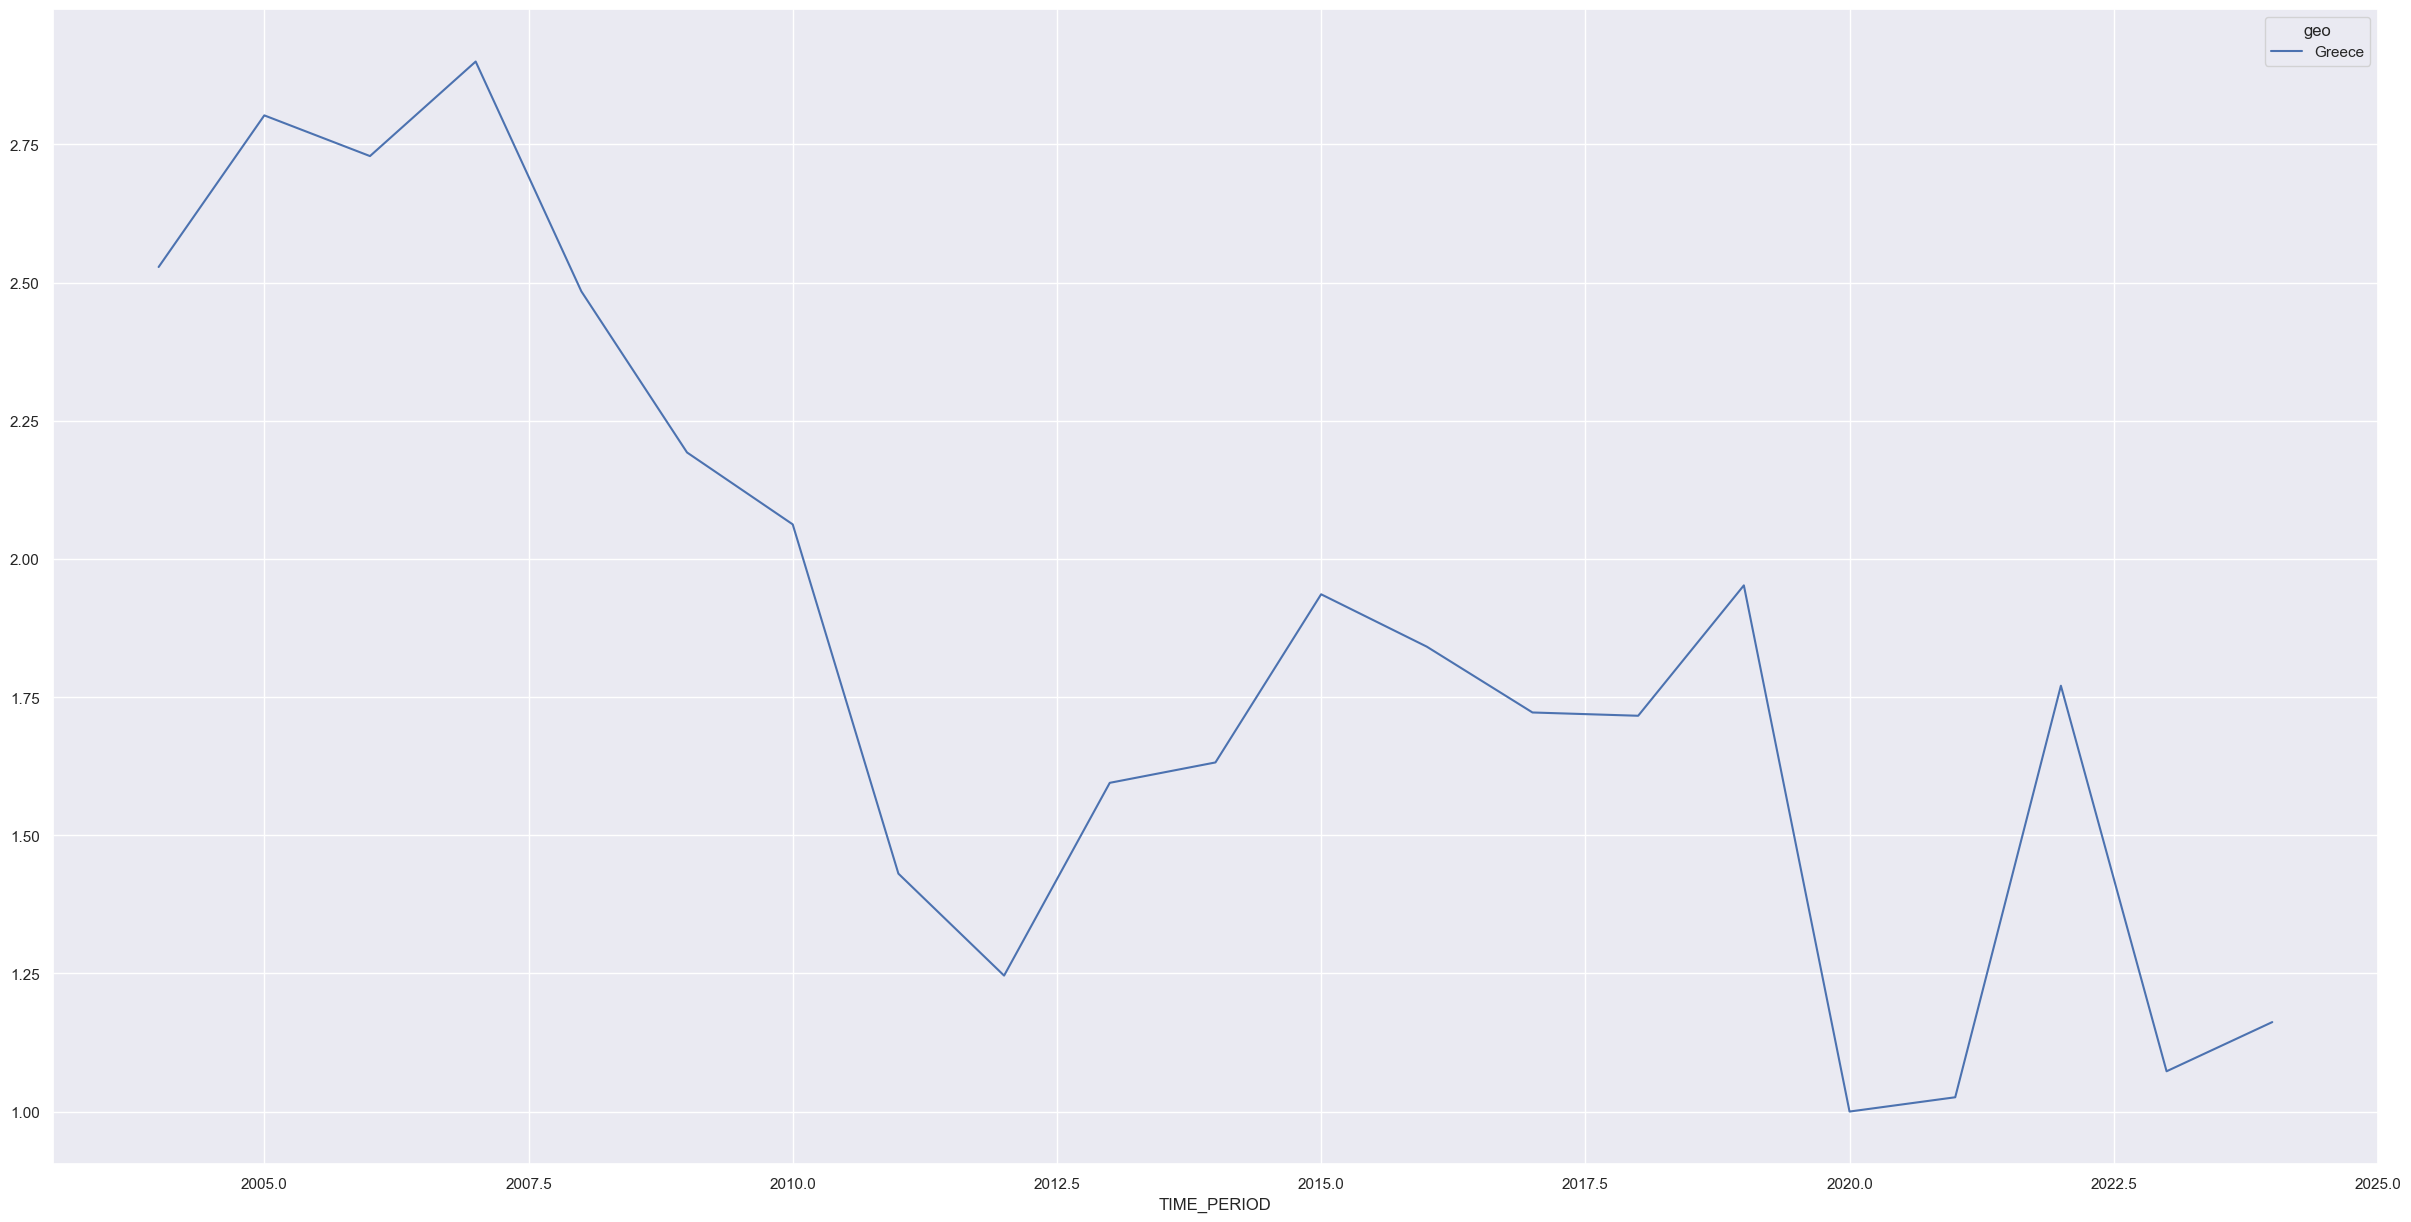

In [112]:
cp_idx = country_passengers / country_passengers.agg('min')
sns.set_theme()
sns.set(rc={"figure.figsize":(30, 15)})
sns.lineplot(cp_idx.iloc[:, 10:11])


In [113]:
cp_idx

geo,Austria,Belgium,Bulgaria,Croatia,Czechia,Denmark,Estonia,Finland,France,Germany,...,Poland,Portugal,Romania,Slovakia,Slovenia,Spain,Sweden,Switzerland,Türkiye,United Kingdom
TIME_PERIOD,,,,,,,,,,,,,,,,,,,,,
2004,1.226405,2.974924,NaN,2.383804,1.042094,1.621153,1.000000,1.258235,1.493604,1.329606,...,1.810226,1.450259,2.085502,1.150055,2.158618,1.874566,1.243826,NaN,4.264228,1.000000
2005,1.278097,2.731361,NaN,2.499096,1.055509,1.627953,1.291972,1.301324,1.532498,1.313298,...,1.757172,1.469258,1.940360,1.126141,2.222555,1.916723,1.278499,NaN,4.050945,1.020241
2006,1.302360,2.859140,1.856881,2.691572,1.093230,1.660170,1.346936,1.319741,1.579309,1.380782,...,1.793139,1.492640,1.977955,1.142089,2.240917,1.927455,1.374401,NaN,4.192388,1.073103
2007,1.335735,2.978435,1.865352,3.201830,1.086183,1.672095,1.444353,1.402764,1.611308,1.389222,...,1.920957,1.532382,1.838325,1.117265,2.282443,1.871510,1.455897,NaN,4.356653,1.136692
2008,1.505751,3.186777,1.810920,3.602092,1.057304,1.691398,1.449187,1.497821,1.691234,1.449417,...,1.944875,1.616060,1.751996,1.184232,2.359680,2.014916,1.569468,1.512634,3.950383,1.183962
2009,1.474662,3.191782,1.682404,3.671136,1.002335,1.652031,1.319624,1.425815,1.722934,1.431682,...,1.783119,1.614580,1.557738,1.166353,2.358437,1.956292,1.581466,1.558593,4.110859,1.169726
2010,1.483141,3.246942,1.654682,3.491375,1.012284,1.693143,1.311430,1.449513,1.977054,1.464009,...,1.724983,1.573931,1.392002,1.187768,2.208313,1.885789,1.544207,1.591466,4.139912,1.228431
2011,1.553191,3.251616,1.641716,2.982079,1.026842,1.755423,1.293715,1.415014,2.033351,1.609608,...,1.737763,1.622287,1.302386,1.250054,2.083872,1.927929,1.562687,1.598657,2.969743,1.275863
2012,1.609257,NaN,1.499608,2.217635,1.106012,1.785978,1.255318,1.463707,1.748214,1.690313,...,1.741754,1.458014,1.176426,1.261673,1.987992,1.881064,1.607915,1.564781,2.200757,1.316644


In [114]:
df3 = df.copy()

In [115]:
countries = df['geo'].unique()
countries = [c for c in countries if c not in ['Ukraine', 'Lichtenstein','Bosnia and Herzegovina']]
def get_subset(df, part):
    end = int(len(countries) / 4 * part)
    start = int(end - len(countries)/4)
    print(f"{start}:{end}")
    return df[df['geo'].str.match('|'.join(countries[start:end]))]

0:8
0:8


<Axes: xlabel='TIME_PERIOD', ylabel='passengers_per_capita'>

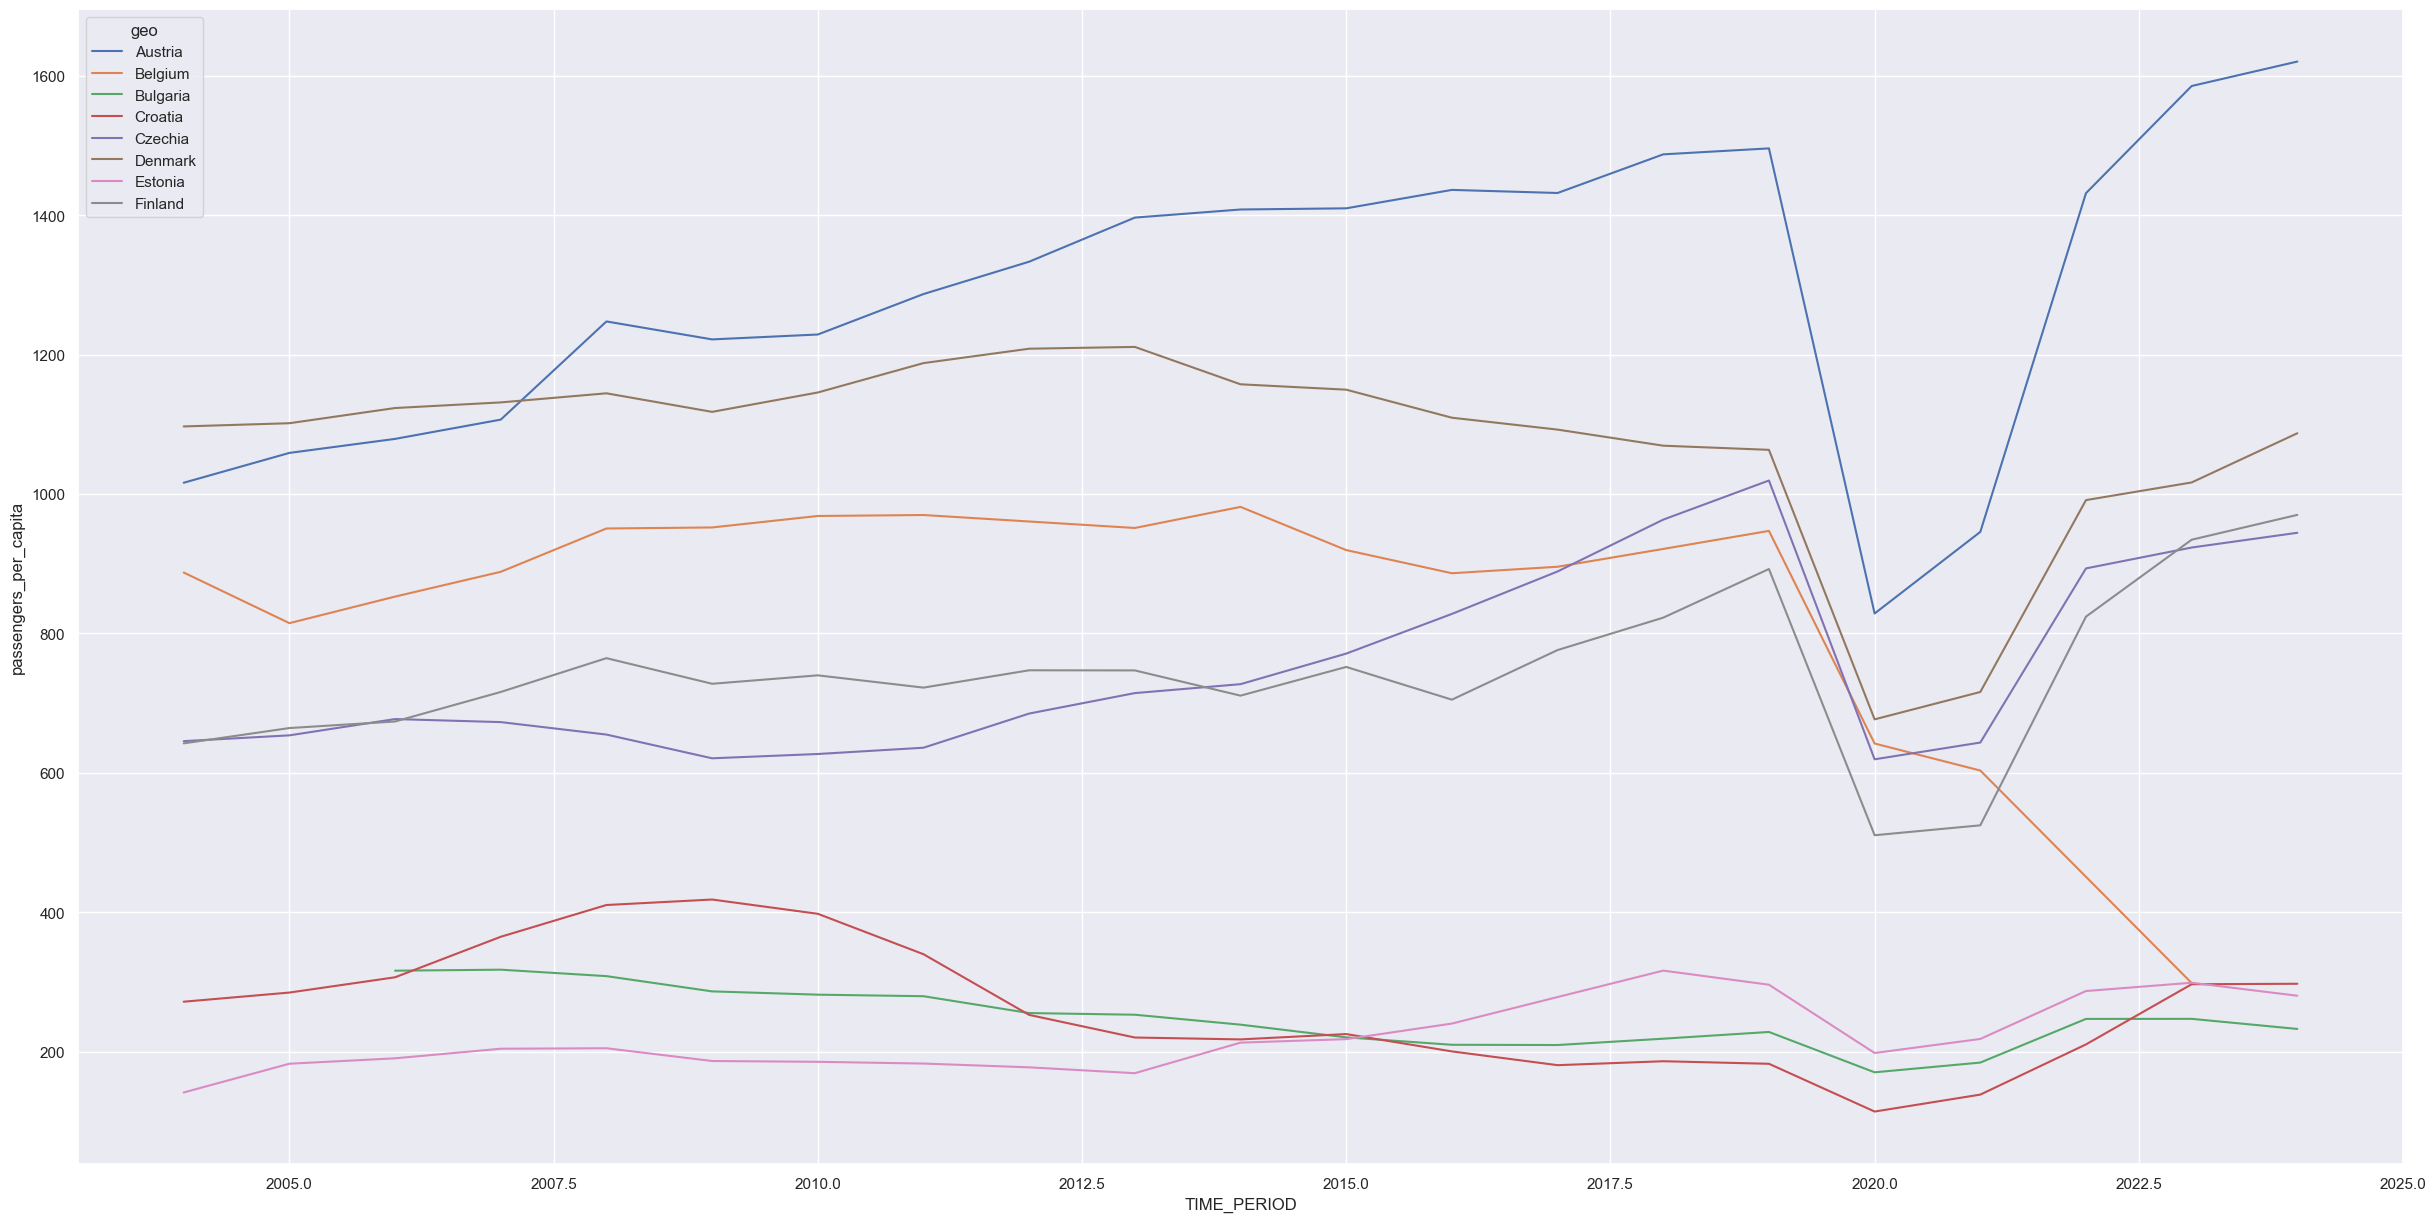

In [116]:
get_subset(df3, 1)
sns.lineplot(get_subset(df3, 1), x='TIME_PERIOD', y='passengers_per_capita', hue='geo')

8:16
               geo  TIME_PERIOD  Passengers_Mil_KM  km_railways  population  \
176         France         2004            74359.0      31033.0  62292241.0   
177         France         2005            76884.0      31024.0  62772870.0   
178         France         2006            79809.0      31036.0  63229635.0   
179         France         2007            81961.0      31307.0  63645065.0   
180         France         2008            86516.0      31194.0  64007193.0   
..             ...          ...                ...          ...         ...   
339  Liechtenstein         2020                8.0          9.0     38747.0   
340  Liechtenstein         2021               12.0          9.0     39055.0   
341  Liechtenstein         2022               27.0          9.0     39308.0   
342  Liechtenstein         2023               28.0          9.0     39677.0   
343  Liechtenstein         2024               29.0          9.0     40015.0   

        GDP_Capita      area  passengers_per_c

<Axes: xlabel='TIME_PERIOD', ylabel='passengers_per_capita'>

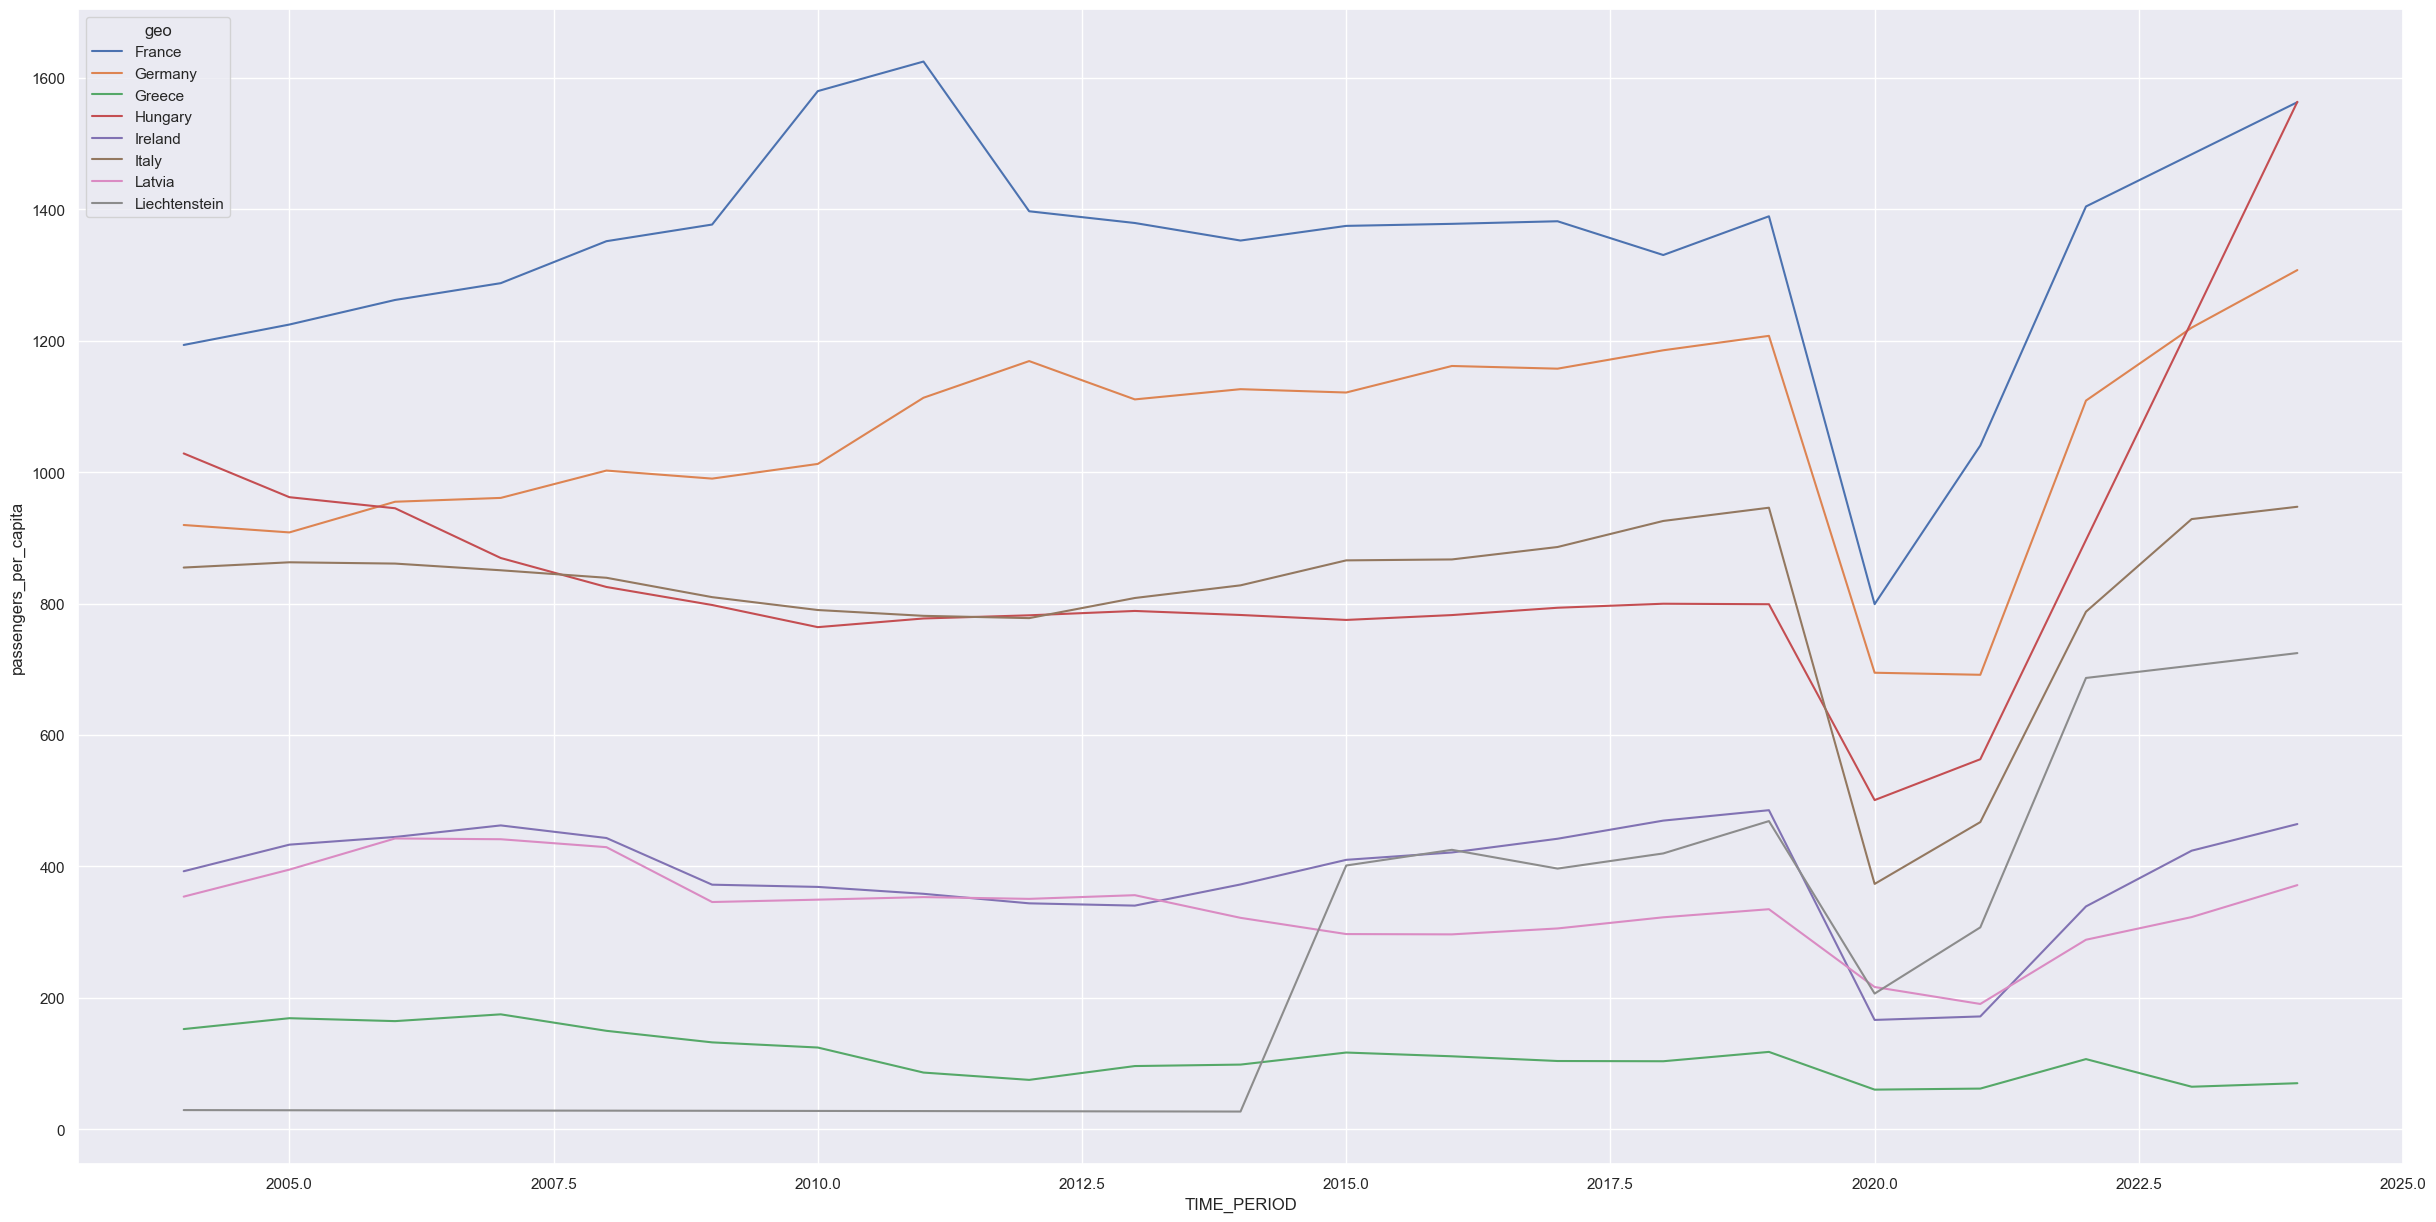

In [117]:
print(get_subset(df3, 2))
sns.lineplot(get_subset(df3, 2), x='TIME_PERIOD', y='passengers_per_capita', hue='geo')

16:24


<Axes: xlabel='TIME_PERIOD', ylabel='passengers_per_capita'>

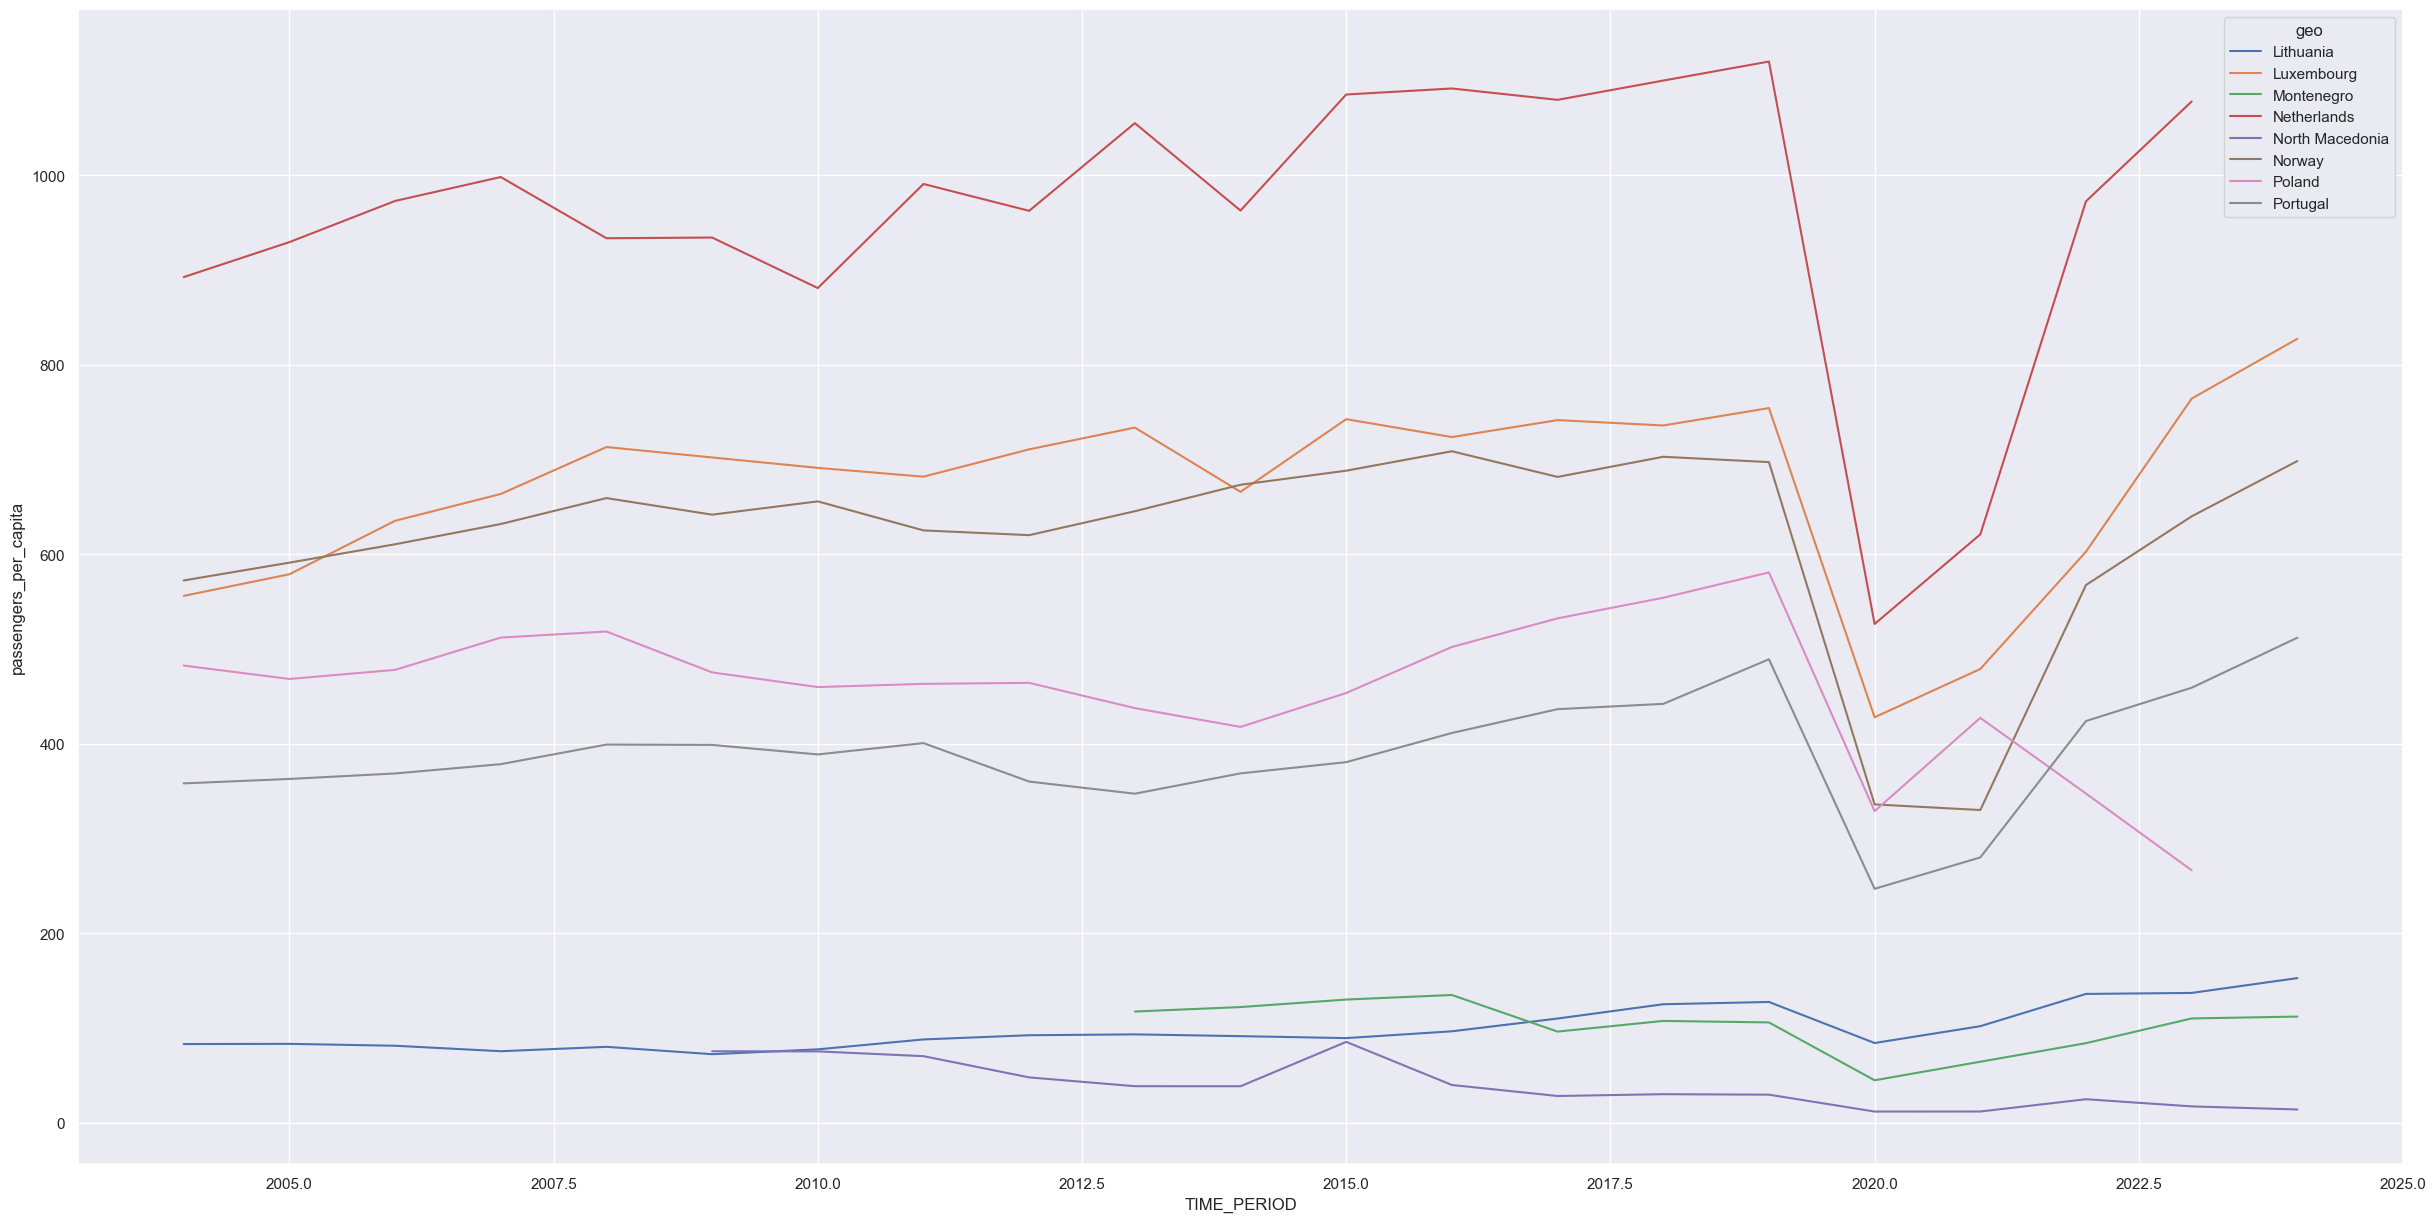

In [118]:
sns.lineplot(get_subset(df3, 3), x='TIME_PERIOD', y='passengers_per_capita', hue='geo')

24:32


<Axes: xlabel='TIME_PERIOD', ylabel='passengers_per_capita'>

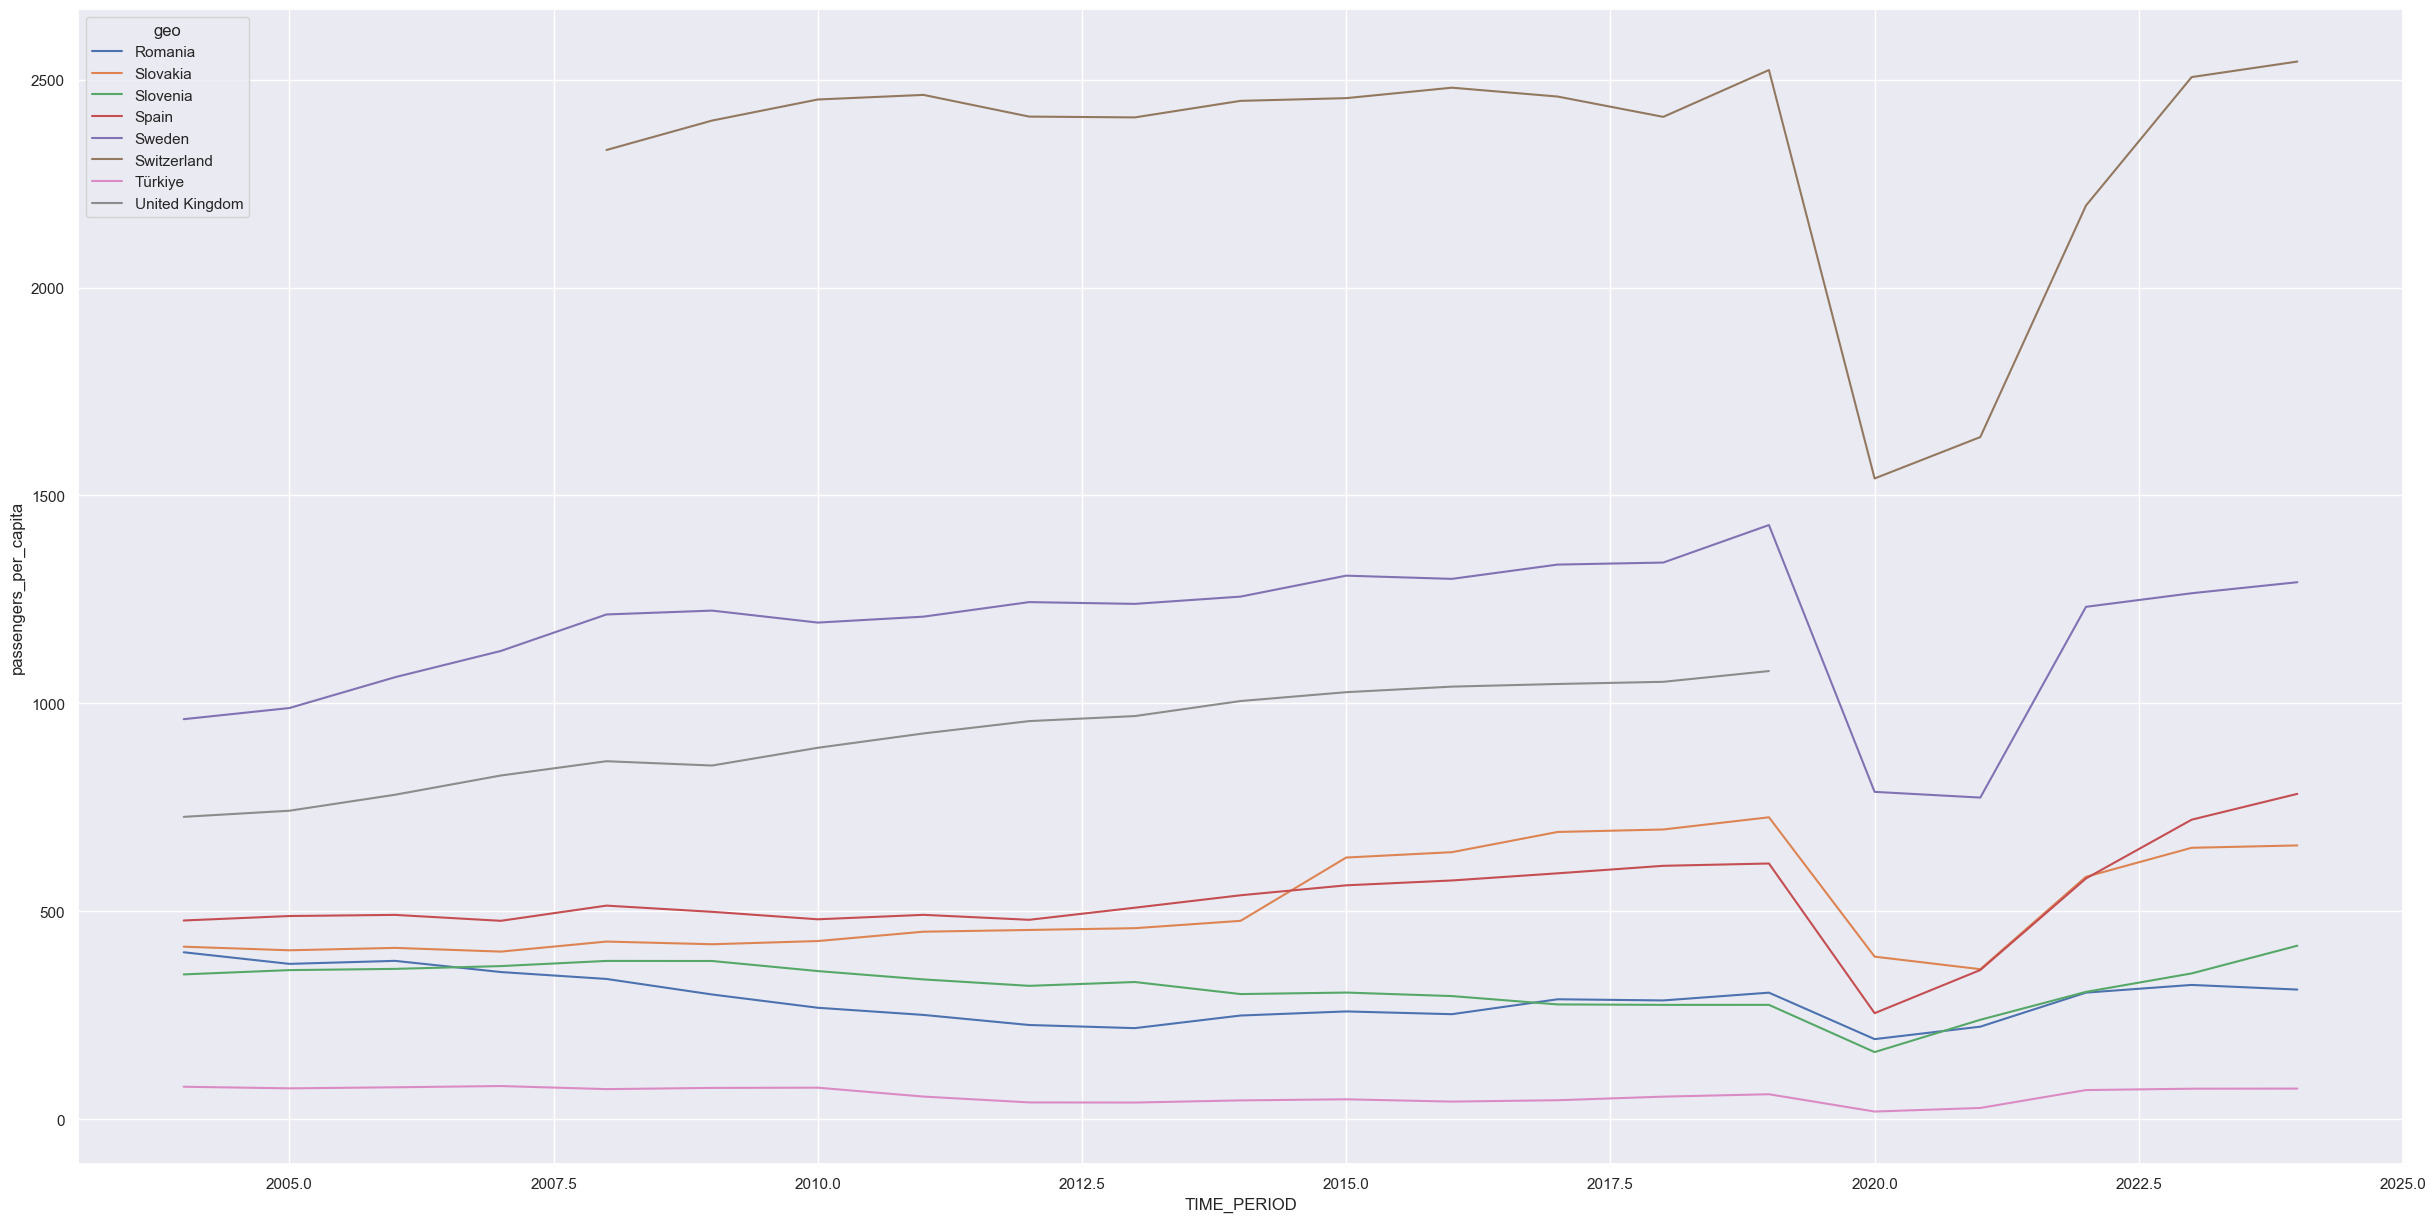

In [119]:
sns.lineplot(get_subset(df3, 4), x='TIME_PERIOD', y='passengers_per_capita', hue='geo')

In [120]:
cp_idx['United Kingdom']

TIME_PERIOD
2004    1.000000
2005    1.020241
2006    1.073103
2007    1.136692
2008    1.183962
2009    1.169726
2010    1.228431
2011    1.275863
2012    1.316644
2013    1.333308
2014    1.383081
2015    1.412306
2016    1.430739
2017    1.439474
2018    1.446625
2019    1.482206
2020         NaN
2021         NaN
2022         NaN
2023         NaN
2024         NaN
Name: United Kingdom, dtype: float64

In [121]:
df[df['geo'] == 'United Kingdom']

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita,area,passengers_per_capita,rail_density,gdp_per_km_rail
643,United Kingdom,2004,43474.0,16458.0,59793759.0,40504.411810,248536.0,727.065846,0.066220,2.461077
644,United Kingdom,2005,44642.0,15810.0,60182050.0,42240.246299,248536.0,741.782641,0.063613,2.671742
645,United Kingdom,2006,47297.0,15795.0,60620361.0,44695.161023,248536.0,780.216403,0.063552,2.829703
646,United Kingdom,2007,50474.0,15814.0,61073279.0,50629.079917,248536.0,826.449813,0.063629,3.201535
647,United Kingdom,2008,53002.0,16160.0,61571647.0,47652.403069,248536.0,860.818292,0.065021,2.948787
648,United Kingdom,2009,52765.0,16126.0,62042343.0,39009.371555,248536.0,850.467559,0.064884,2.419036
649,United Kingdom,2010,55831.0,16223.0,62510197.0,39778.322053,248536.0,893.150281,0.065274,2.451971
650,United Kingdom,2011,58462.0,16210.0,63022532.0,42295.927384,248536.0,927.636484,0.065222,2.609249
651,United Kingdom,2012,60783.0,16195.0,63495088.0,42688.326373,248536.0,957.286649,0.065162,2.635895
652,United Kingdom,2013,61950.0,16195.0,63905342.0,43606.983790,248536.0,969.402527,0.065162,2.692620


In [122]:
dfPassengers[dfPassengers['Entity'] == 'United Kingdom']

,Entity,Code,Year,"Railways, passengers carried (passenger-km)"
2179,United Kingdom,GBR,1995,37200.000
2180,United Kingdom,GBR,1996,39200.000
2181,United Kingdom,GBR,1997,42200.000
2182,United Kingdom,GBR,1998,44100.000
2183,United Kingdom,GBR,1999,46800.000
2184,United Kingdom,GBR,2000,46506.215
2185,United Kingdom,GBR,2001,47471.883
2186,United Kingdom,GBR,2002,47992.684
2187,United Kingdom,GBR,2003,49224.355
2188,United Kingdom,GBR,2004,50018.277


📊 MODEL PERFORMANCE
--------------------
MAE  : 4272.83
RMSE : 6902.52
R²   : 0.929


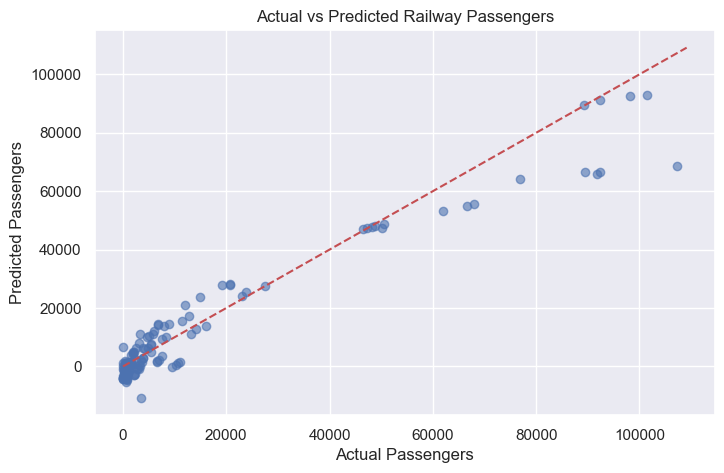

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

features = [
    "GDP_Capita",
    "population",
    "km_railways",
    "rail_density",
    "area",
    "passengers_per_capita",
    "gdp_per_km_rail"
]

target = "Passengers_Mil_KM"

df_model = df.dropna(subset=features + [target])
df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna()

df_model.describe()

X = df_model[features]
y = df_model[target]

# -------------------------
# 2. TRAIN / TEST SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -------------------------
# 3. MODEL PIPELINE
# -------------------------
model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

# -------------------------
# 4. TRAINING
# -------------------------
model.fit(X_train, y_train)

# -------------------------
# 5. PREDICTIONS
# -------------------------
y_pred = model.predict(X_test)

# -------------------------
# 6. METRICS
# -------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📊 MODEL PERFORMANCE")
print("--------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

# -------------------------
# 7. VISUALIZATION
# -------------------------
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Passengers")
plt.ylabel("Predicted Passengers")
plt.title("Actual vs Predicted Railway Passengers")
plt.show()

<Axes: >

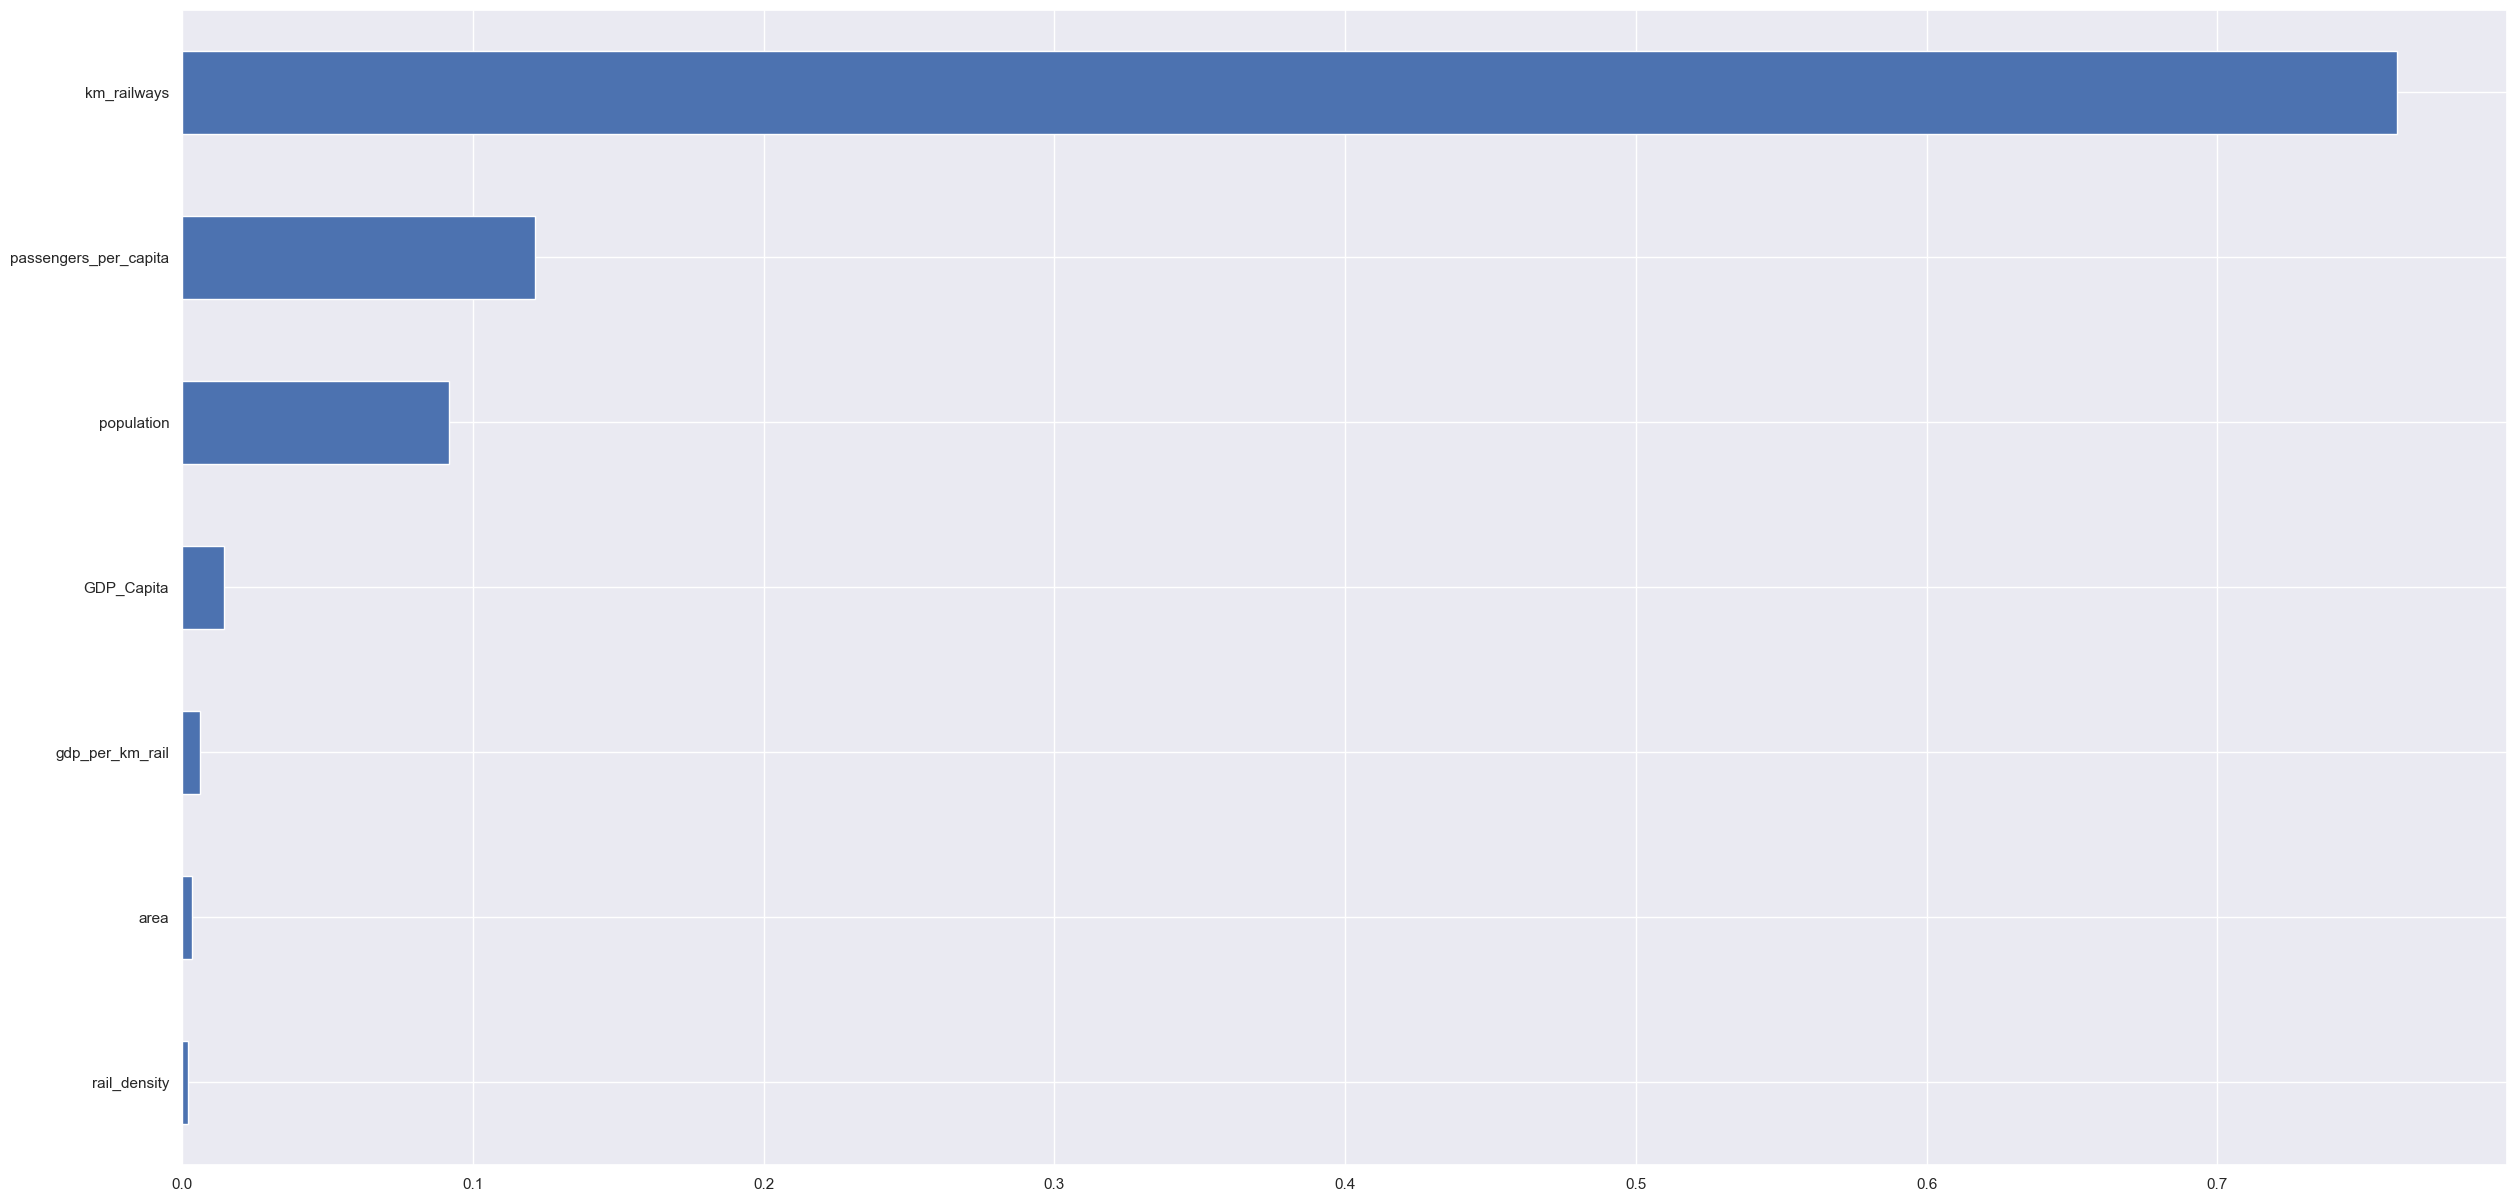

In [153]:
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind='barh')

In [124]:
df_model.describe()


,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita,area,passengers_per_capita,rail_density,gdp_per_km_rail
count,631.000000,631.000000,631.000000,6.310000e+02,631.000000,631.000000,631.000000,631.000000,631.000000
mean,2014.191759,14163.940597,7742.278160,1.913511e+07,33730.594157,184168.195404,635.108770,0.051938,364.468575
std,5.940952,23645.472248,8827.950644,2.432491e+07,29656.023857,197144.573782,482.533082,0.031514,2596.931586
min,2004.000000,1.000000,9.000000,3.683800e+04,4450.000000,160.000000,12.040910,0.011099,0.386173
25%,2009.000000,966.500000,2045.000000,4.282920e+06,13580.000000,45227.000000,280.878881,0.027075,1.819031
50%,2014.000000,4535.000000,3897.000000,8.772865e+06,23560.000000,83879.000000,513.543790,0.046242,6.858526
75%,2019.000000,13284.500000,10766.500000,1.926525e+07,43900.000000,312679.000000,924.522966,0.065916,14.735557
max,2024.000000,109135.000000,40202.000000,8.537238e+07,206780.590353,783562.000000,2543.555430,0.128793,22975.621150


In [125]:
X_train

,GDP_Capita,population,km_railways,rail_density,area,passengers_per_capita,gdp_per_km_rail
6,42280.0,8351643.0,5828.00,0.069481,83879.0,1228.859998,7.254633
116,51790.0,5447084.0,2606.00,0.060712,42924.0,1131.431056,19.873369
126,53200.0,5748769.0,2481.00,0.057800,42924.0,1092.407783,21.442967
573,26930.0,46918951.0,16006.02,0.031636,505944.0,614.826193,1.682492
418,4800.0,2057284.0,699.00,0.027185,25713.0,70.481275,6.866953
...,...,...,...,...,...,...,...
83,12320.0,4131115.0,2604.00,0.046012,56594.0,200.188085,4.731183
118,48460.0,5511451.0,2606.00,0.060712,42924.0,1117.854445,18.595549
282,31850.0,58044368.0,16225.00,0.053712,302073.0,862.926098,1.963020
457,9570.0,38115641.0,20196.00,0.064590,312679.0,518.474817,0.473856


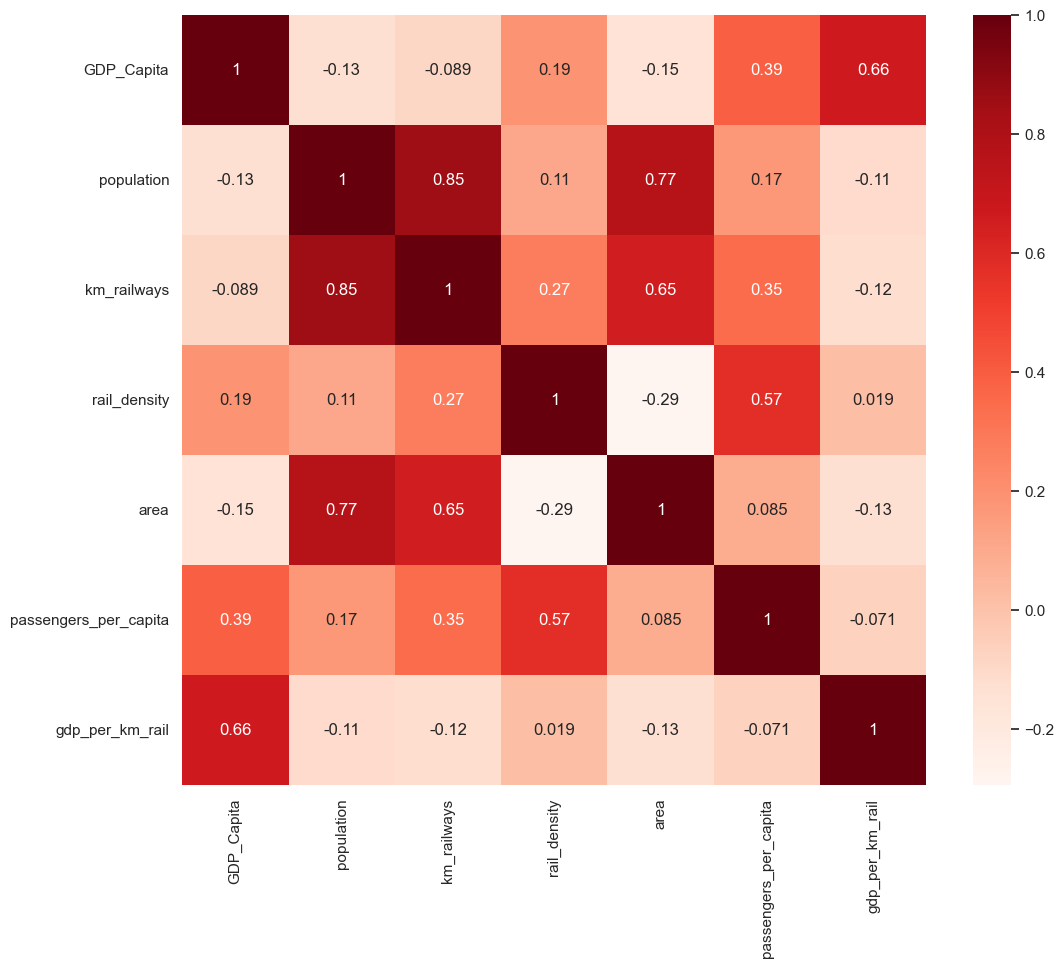

In [126]:
data = pd.DataFrame(df_model[features], columns=features)
corr_matrix = data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap=plt.cm.Reds)
plt.show()


In [127]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita,area,passengers_per_capita,rail_density,gdp_per_km_rail
0,Austria,2004,8274.0,5675.0,8142573.0,39620.000000,83879.0,1016.140721,0.067657,6.981498
1,Austria,2005,8685.0,5691.0,8201359.0,40270.000000,83879.0,1058.970836,0.067848,7.076085
2,Austria,2006,8907.0,5702.0,8254298.0,41370.000000,83879.0,1079.074199,0.067979,7.255349
3,Austria,2007,9167.0,5702.0,8282984.0,42790.000000,83879.0,1106.726755,0.067979,7.504384
4,Austria,2008,10365.0,5693.0,8307989.0,43270.000000,83879.0,1247.594334,0.067872,7.600562
...,...,...,...,...,...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0,45255.344922,248536.0,1026.839105,0.065347,2.786488
655,United Kingdom,2016,68010.0,16253.0,65379044.0,41257.908555,248536.0,1040.241580,0.065395,2.538480
656,United Kingdom,2017,68912.0,16320.0,65844142.0,40916.811507,248536.0,1046.592725,0.065665,2.507158
657,United Kingdom,2018,69706.0,16289.0,66273576.0,43702.997630,248536.0,1051.791743,0.065540,2.682976


In [128]:
df[df["geo"] == "Ukraine"]


,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita,area,passengers_per_capita,rail_density,gdp_per_km_rail
638,Ukraine,2020,10696.0,19790.0,41732779.0,3709.769287,0.0,256.297334,inf,0.187457
639,Ukraine,2021,15709.0,19731.0,41418717.0,4775.945801,0.0,379.272975,inf,0.242053
640,Ukraine,2022,10904.0,19772.0,40997698.0,4199.670898,0.0,265.966153,inf,0.212405
641,Ukraine,2023,15487.0,19760.0,37732836.0,5139.598145,0.0,410.438272,inf,0.260101
642,Ukraine,2024,16699.0,NaN,37860221.0,5389.473145,0.0,441.069797,NaN,NaN


In [129]:
df = df.drop(df[df["geo"] == "Ukraine"].index)

In [130]:
df = df.drop(df[df["geo"] == "Liechtenstein"].index)

In [131]:
df = df.drop(df[df["geo"] == "Bosnia and Herzegovina"].index)

In [132]:
df = df.drop(df[df["geo"] == "Montenegro"].index)

In [133]:
# --- 3. Drop righe con target o feature chiave mancanti ---
before = len(df)
df = df.dropna(subset=['passengers_per_capita', 'Passengers_Mil_KM',
                        'km_railways', 'GDP_Capita'])
print(f"Righe droppate per missing values: {before - len(df)}")

Righe droppate per missing values: 2


In [134]:
df



,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita,area,passengers_per_capita,rail_density,gdp_per_km_rail
0,Austria,2004,8274.0,5675.0,8142573.0,39620.000000,83879.0,1016.140721,0.067657,6.981498
1,Austria,2005,8685.0,5691.0,8201359.0,40270.000000,83879.0,1058.970836,0.067848,7.076085
2,Austria,2006,8907.0,5702.0,8254298.0,41370.000000,83879.0,1079.074199,0.067979,7.255349
3,Austria,2007,9167.0,5702.0,8282984.0,42790.000000,83879.0,1106.726755,0.067979,7.504384
4,Austria,2008,10365.0,5693.0,8307989.0,43270.000000,83879.0,1247.594334,0.067872,7.600562
...,...,...,...,...,...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0,45255.344922,248536.0,1026.839105,0.065347,2.786488
655,United Kingdom,2016,68010.0,16253.0,65379044.0,41257.908555,248536.0,1040.241580,0.065395,2.538480
656,United Kingdom,2017,68912.0,16320.0,65844142.0,40916.811507,248536.0,1046.592725,0.065665,2.507158
657,United Kingdom,2018,69706.0,16289.0,66273576.0,43702.997630,248536.0,1051.791743,0.065540,2.682976


In [135]:
# --- 4. Ricalcolo feature derivate con formula verificata ---
df['rail_density'] = df['km_railways'] / df['area']
df['gdp_per_km_rail'] = df['GDP_Capita'] / df['km_railways']
df['passengers_per_capita'] = df['Passengers_Mil_KM'] * 1e6 / df['population']

# --- 5. Verifica finale ---
assert np.isinf(df.select_dtypes(include=[np.number])).sum().sum() == 0, "Inf residui!"
assert df.isna().sum().sum() == 0, "NaN residui!"
print(f"Shape finale dataset pulito: {df.shape}")


Shape finale dataset pulito: (609, 10)


In [136]:
PROFILE_YEARS = range(2013, 2019)
profile = df[df['TIME_PERIOD'].isin(PROFILE_YEARS)].groupby('geo').agg(
    passengers_per_capita=('passengers_per_capita', 'mean'),
    rail_density=('rail_density', 'mean'),
    GDP_Capita=('GDP_Capita', 'mean'),
    population=('population', 'mean'),
    area=('area', 'mean'),
).reset_index()




In [137]:
profile['pop_density'] = profile['population'] / profile['area']

In [138]:
profile

,geo,passengers_per_capita,rail_density,GDP_Capita,population,area,pop_density
0,Austria,1428.402572,0.065825,43716.666667,8.640029e+06,83879.0,103.005868
1,Belgium,925.896208,0.118181,40490.000000,1.126959e+07,30528.0,369.155753
2,Bulgaria,224.870435,0.036488,8333.333333,6.982566e+06,110370.0,63.265069
3,Croatia,204.887041,0.046359,12193.333333,4.145096e+06,56594.0,73.242673
4,Czechia,815.417360,0.121274,19575.000000,1.055159e+07,78868.0,133.787969
5,Denmark,1131.558963,0.059330,51623.333333,5.687798e+06,42924.0,132.508573
6,Estonia,238.988501,0.025718,19165.000000,1.316662e+06,45227.0,29.112296
7,Finland,752.158193,0.017526,41713.333333,5.475572e+06,338440.0,16.178856
8,France,1366.268649,0.046370,35626.666667,6.644982e+07,633186.6,104.945081
9,Germany,1143.930243,0.108400,41735.000000,8.166307e+07,357376.0,228.507433


In [139]:
from sklearn.metrics import silhouette_score


CLUSTER_FEATURES = ['passengers_per_capita', 'rail_density', 'GDP_Capita', 'pop_density']
X = profile[CLUSTER_FEATURES].copy()

# Standardizzazione: K-means e' sensibile alla scala (GDP in decine di migliaia
# vs rail_density in frazioni di unita')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Scelta di k: elbow + silhouette ---
print("\n=== SCELTA K ===")
results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    results.append((k, km.inertia_, sil))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil:.3f}")


=== SCELTA K ===
k=2: inertia=66.5, silhouette=0.401
k=3: inertia=48.1, silhouette=0.382
k=4: inertia=37.1, silhouette=0.401
k=5: inertia=28.2, silhouette=0.351
k=6: inertia=21.8, silhouette=0.364
k=7: inertia=16.3, silhouette=0.388
k=8: inertia=13.6, silhouette=0.366


In [140]:
X

,passengers_per_capita,rail_density,GDP_Capita,pop_density
0,1428.402572,0.065825,43716.666667,103.005868
1,925.896208,0.118181,40490.000000,369.155753
2,224.870435,0.036488,8333.333333,63.265069
3,204.887041,0.046359,12193.333333,73.242673
4,815.417360,0.121274,19575.000000,133.787969
5,1131.558963,0.059330,51623.333333,132.508573
6,238.988501,0.025718,19165.000000,29.112296
7,752.158193,0.017526,41713.333333,16.178856
8,1366.268649,0.046370,35626.666667,104.945081
9,1143.930243,0.108400,41735.000000,228.507433


In [141]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)
labels

array([2, 1, 0, 0, 1, 2, 0, 2, 2, 1, 0, 0, 2, 1, 0, 0, 2, 1, 0, 2, 0, 0,
       0, 0, 0, 0, 2, 3, 0, 1], dtype=int32)

In [142]:

from sklearn import decomposition
# keep the first two principal components
pca = decomposition.PCA(n_components=2)
# fit pca model to the survey
survey_pca = pca.fit(X_scaled)

In [143]:
cluster_centers = pd.DataFrame(km.cluster_centers_, columns=CLUSTER_FEATURES)
cluster_centers

,passengers_per_capita,rail_density,GDP_Capita,pop_density
0,-0.731366,-0.397144,-0.777423,-0.417588
1,0.541088,1.164689,0.227736,1.574437
2,0.543850,-0.415125,1.039527,-0.505174
3,3.373160,2.290019,1.978712,0.858586


In [144]:
# projecting the values on the pca directions
df_pca = pca.transform(X_scaled)
# controling shape of the dataset
print("Orignial shape: {}". format(str(X_scaled.shape)))
print("Reduced shape: {}".format(str(df_pca.shape)))

Orignial shape: (30, 4)
Reduced shape: (30, 2)


In [145]:
# saving data as dataframe
df_pca = pd.DataFrame(df_pca, columns = ['Pc1', 'Pc2'])
df_pca.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pc1     30 non-null     float64
 1   Pc2     30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [146]:
df_pca['cluster'] = km.labels_
# Convert 'cluster' to a categorical variable with a specified order
order = [0, 1, 2, 3]
df_pca['cluster'] = pd.Categorical(df_pca['cluster'], categories=order, ordered=True)


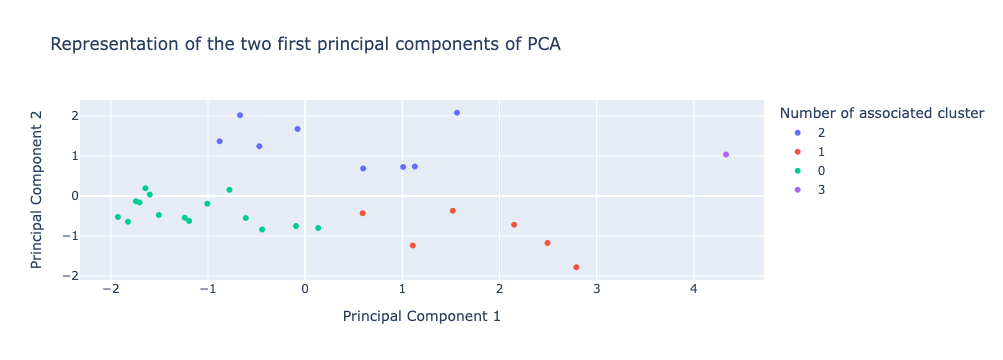

In [147]:
import plotly.express as px

fig = px.scatter(df_pca, x="Pc1", y="Pc2",color="cluster",
                 labels= {
                     "Pc1": "Principal Component 1",
                     "Pc2": "Principal Component 2",
                     "cluster": "Number of associated cluster"
                 },
                 title= "Representation of the two first principal components of PCA") 
fig.show()

In [151]:
profile['cluster'] = km.labels_
print(profile[['geo', 'cluster']].sort_values('cluster').to_string())

                geo  cluster
14           Latvia        0
25            Spain        0
2          Bulgaria        0
3           Croatia        0
24         Slovenia        0
23         Slovakia        0
6           Estonia        0
22          Romania        0
21         Portugal        0
20           Poland        0
10           Greece        0
11          Hungary        0
18  North Macedonia        0
28          Türkiye        0
15        Lithuania        0
17      Netherlands        1
29   United Kingdom        1
13            Italy        1
9           Germany        1
4           Czechia        1
1           Belgium        1
12          Ireland        2
19           Norway        2
8            France        2
7           Finland        2
5           Denmark        2
26           Sweden        2
16       Luxembourg        2
0           Austria        2
27      Switzerland        3


Cluster 0 — Basso utilizzo (15 paesi)
Latvia, Spain, Bulgaria, Croatia, Slovenia, Slovakia, Estonia, Romania, Portugal, Poland, Greece, Hungary, North Macedonia, Türkiye, Lithuania
Perlopiù Europa dell'Est + periferia mediterranea. PIL più basso, rete ferroviaria meno densa.

Cluster 1 — Medio utilizzo (6 paesi)
Netherlands, United Kingdom, Italy, Germany, Czechia, Belgium
Grandi economie dell'Europa occidentale/centrale con reti sviluppate ma alta densità di auto.

Cluster 2 — Alto utilizzo (8 paesi)
Ireland, Norway, France, Finland, Denmark, Sweden, Luxembourg, Austria
→ Nord Europa + Francia + Austria. Alto PIL pro capite, forte cultura del trasporto pubblico.

Cluster 3 — Outlier (1 paese)
Switzerland

→ Da solo perché ha valori estremi su tutte le dimensioni: PIL altissimo, rete ferroviaria densissima, e utilizzo pro capite fuori scala rispetto a tutti gli altri.
La Svizzera come outlier è in realtà un risultato interessante da commentare nella Transferarbeit — ha la rete ferroviaria più utilizzata pro capite d'Europa ed è strutturalmente diversa dagli altri paesi.

In [ ]:
3